<a href="https://colab.research.google.com/github/harshbansal-ai/Paytm-Merchant-Settlement-Reconciliation-Control-System/blob/main/SQL_Developer_Paytm_FinTech_Merchant_Settlement_and_Reconciliation_Control_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Paytm Merchant Settlement and Reconciliation Control System
## SQL Developer Colab

**Industry:** FinTech  
**Role:** SQL Developer  
**Runtime:** Google Colab  
**Main skills:** Database design, API consumption, SQL, transactions, workflow automation, and engineering practices

A fintech operations team needs a reliable way to compare merchant payments, refunds, settlement batches, and bank credits. The technical environment is already prepared. You will complete only the clearly marked developer activities.

# Project Summary

Developed a SQL-led Paytm Merchant Settlement & Reconciliation Control System using Python, SQLite, REST APIs, and SQL. The project integrates merchant, transaction, refund, settlement, and bank-credit data to validate settlements, detect reconciliation exceptions, and generate operational reports. It also demonstrates database constraints, transaction control, API CRUD operations, SQL analytics, automation workflows, and Git-based engineering practices

## How to Use This Notebook

1. Open **Runtime → Run all** once.
2. Wait until you see the green **SETUP COMPLETE** message.
3. Scroll to the large **SQL DEVELOPER WORK STARTS HERE** heading.
4. Edit only cells containing **✍️ SQL DEVELOPER WORKSPACE**.
5. After each answer, rerun that cell until **Overall status: Passed** appears.

### Fast navigation

Use the notebook table of contents or search for:

```text
SQL DEVELOPER WORKSPACE
```

All setup cells are grouped under one heading and can be ignored after they run successfully.

# 1. RUN THIS SETUP ONCE — DO NOT EDIT

Everything required for the project is created in this section:

- Dataset
- Temporary internal REST API
- Raw and processed datasets
- SQLite database
- Reconciliation exceptions
- Validation helpers
- ER and workflow diagram helpers

You may run the entire notebook. Unanswered developer cells will only show a safe `TODO` message and will not break the setup.

## 1.1 Environment and Project Folder

In [ ]:
from __future__ import annotations

import json
import math
import os
import random
import re
import shutil
import sqlite3
import subprocess
import sys
import threading
import time
from collections import defaultdict
from datetime import date, datetime, timedelta
from http.server import BaseHTTPRequestHandler, ThreadingHTTPServer
from pathlib import Path
from urllib.parse import parse_qs, urlparse

import pandas as pd
import requests
from IPython.display import Markdown, display

try:
    from graphviz import Digraph
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "graphviz"])
    from graphviz import Digraph

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

BASE_DIR = Path("/content") if Path("/content").exists() else Path.cwd()
PROJECT_ROOT = BASE_DIR / "paytm_sql_project_developer"

if PROJECT_ROOT.exists():
    shutil.rmtree(PROJECT_ROOT)

for folder in [
    "data/raw",
    "data/processed",
    "database",
    "logs",
    "reports",
]:
    (PROJECT_ROOT / folder).mkdir(parents=True, exist_ok=True)

print("✅ Environment ready")
print("Project root:", PROJECT_ROOT)

✅ Environment ready
Project root: /content/paytm_sql_project_developer


## 1.2 Dataset

In [ ]:
SEED = 20260806
rng = random.Random(SEED)

CITIES = ["Bengaluru", "Mumbai", "Delhi", "Hyderabad", "Chennai", "Pune", "Kolkata", "Ahmedabad"]
CATEGORIES = ["Grocery", "Electronics", "Fashion", "Food & Beverage", "Travel", "Education", "Pharmacy", "Services"]
PAYMENT_METHODS = ["UPI", "CARD", "WALLET", "NET_BANKING"]
FEE_RATES = {"UPI": 0.005, "CARD": 0.018, "WALLET": 0.012, "NET_BANKING": 0.010}

# ---------------------------
# Merchant records
# ---------------------------
merchant_names = []
for i in range(1, 51):
    prefix = rng.choice(["Nova", "Urban", "Prime", "Shree", "Blue", "Green", "Smart", "Quick", "Metro", "Royal"])
    suffix = rng.choice(["Mart", "Store", "Foods", "Services", "Retail", "Hub", "Bazaar", "Works"])
    merchant_names.append(f"{prefix} {suffix} {i:02d}")

merchants = []
for i, name in enumerate(merchant_names, 1):
    merchants.append({
        "merchant_id": f"M{i:04d}",
        "merchant_name": name,
        "category": rng.choice(CATEGORIES),
        "city": rng.choice(CITIES),
        "onboarding_date": (date(2024, 1, 1) + timedelta(days=rng.randint(0, 700))).isoformat(),
        "status": rng.choices(["ACTIVE", "SUSPENDED"], [0.94, 0.06])[0],
        "settlement_cycle": rng.choices(["D+1", "D+2"], [0.70, 0.30])[0],
    })

# ----------------------------
# Payment records
# ----------------------------
transactions = []
period_start = datetime(2026, 6, 1)
for i in range(1, 1201):
    merchant = rng.choice(merchants)
    txn_time = period_start + timedelta(minutes=rng.randint(0, 30 * 24 * 60 - 1))
    payment_method = rng.choices(PAYMENT_METHODS, [0.55, 0.22, 0.13, 0.10])[0]
    gross_amount = round(math.exp(rng.uniform(math.log(80), math.log(15000))), 2)
    txn_status = rng.choices(["SUCCESS", "FAILED", "PENDING"], [0.90, 0.06, 0.04])[0]

    fee_amount = round(gross_amount * FEE_RATES[payment_method], 2) if txn_status == "SUCCESS" else 0.0
    # Deliberately introduce a few incorrect fees for reconciliation analysis.
    if txn_status == "SUCCESS" and rng.random() < 0.018:
        fee_amount = round(fee_amount + rng.choice([-1, 1]) * rng.uniform(3, 40), 2)
        fee_amount = max(0.0, fee_amount)

    tax_amount = round(fee_amount * 0.18, 2)
    net_amount = round(gross_amount - fee_amount - tax_amount, 2) if txn_status == "SUCCESS" else 0.0
    settlement_status = (
        rng.choices(["SETTLED", "PENDING", "HOLD"], [0.79, 0.14, 0.07])[0]
        if txn_status == "SUCCESS"
        else "NOT_APPLICABLE"
    )

    transactions.append({
        "transaction_id": f"TXN{i:06d}",
        "merchant_id": merchant["merchant_id"],
        "customer_ref": f"CUST{rng.randint(1, 600):05d}",
        "txn_timestamp": txn_time.isoformat(sep=" "),
        "payment_method": payment_method,
        "gross_amount": gross_amount,
        "fee_amount": fee_amount,
        "tax_amount": tax_amount,
        "net_amount": net_amount,
        "txn_status": txn_status,
        "settlement_status": settlement_status,
        "created_at": txn_time.isoformat(sep=" "),
    })

successful_transactions = [row for row in transactions if row["txn_status"] == "SUCCESS"]

# -------------------------
# Refund records
# -------------------------
refunds = []
for idx, txn in enumerate(rng.sample(successful_transactions, k=int(len(successful_transactions) * 0.11)), 1):
    refund_amount = round(txn["gross_amount"] * rng.choice([0.25, 0.50, 1.00]), 2)
    refund_time = datetime.fromisoformat(txn["txn_timestamp"]) + timedelta(
        days=rng.randint(1, 8), hours=rng.randint(0, 20)
    )
    refunds.append({
        "refund_id": f"REF{idx:05d}",
        "transaction_id": txn["transaction_id"],
        "refund_timestamp": refund_time.isoformat(sep=" "),
        "refund_amount": refund_amount,
        "refund_status": rng.choices(["COMPLETED", "PENDING", "FAILED"], [0.78, 0.15, 0.07])[0],
        "reason": rng.choice(["CUSTOMER_REQUEST", "DUPLICATE_PAYMENT", "ORDER_CANCELLED", "SERVICE_ISSUE"]),
    })

completed_refund_by_txn = defaultdict(float)
for refund in refunds:
    if refund["refund_status"] == "COMPLETED":
        completed_refund_by_txn[refund["transaction_id"]] += refund["refund_amount"]

# --------------------------------------
# Settlement batches and settlement items
# --------------------------------------
settled_transactions = [
    txn for txn in transactions
    if txn["txn_status"] == "SUCCESS" and txn["settlement_status"] == "SETTLED"
]
settlement_groups = defaultdict(list)
for txn in settled_transactions:
    txn_date = datetime.fromisoformat(txn["txn_timestamp"])
    week_number = (txn_date.day - 1) // 7 + 1
    settlement_groups[(txn["merchant_id"], week_number)].append(txn)

merchant_cycle = {merchant["merchant_id"]: merchant["settlement_cycle"] for merchant in merchants}
settlement_batches = []
settlement_items = []

for idx, ((merchant_id, week_number), txns) in enumerate(sorted(settlement_groups.items()), 1):
    batch_period_start = date(2026, 6, 1) + timedelta(days=(week_number - 1) * 7)
    batch_period_end = min(batch_period_start + timedelta(days=6), date(2026, 6, 30))
    cycle_days = 1 if merchant_cycle[merchant_id] == "D+1" else 2
    settlement_date = batch_period_end + timedelta(days=cycle_days)

    calculated_amount = 0.0
    settlement_id = f"SET{idx:05d}"
    for txn in txns:
        adjustment = -min(completed_refund_by_txn.get(txn["transaction_id"], 0.0), txn["net_amount"])
        included_amount = round(txn["net_amount"] + adjustment, 2)
        calculated_amount += included_amount
        settlement_items.append({
            "settlement_id": settlement_id,
            "transaction_id": txn["transaction_id"],
            "included_net_amount": included_amount,
            "adjustment_amount": round(adjustment, 2),
        })

    recorded_expected_amount = round(calculated_amount, 2)
    # A few batches contain a deliberate settlement-engine discrepancy.
    if rng.random() < 0.08:
        recorded_expected_amount = round(
            recorded_expected_amount + rng.choice([-1, 1]) * rng.uniform(20, 500), 2
        )

    settlement_batches.append({
        "settlement_id": settlement_id,
        "merchant_id": merchant_id,
        "settlement_date": settlement_date.isoformat(),
        "period_start": batch_period_start.isoformat(),
        "period_end": batch_period_end.isoformat(),
        "expected_amount": recorded_expected_amount,
        "settlement_status": rng.choices(["PROCESSED", "ON_HOLD"], [0.95, 0.05])[0],
        "expected_bank_reference": f"BNK{idx:07d}",
    })

# -----------------------------
# Bank credit records
# -----------------------------
bank_credits = []
for idx, settlement in enumerate(settlement_batches, 1):
    if rng.random() < 0.09:  # Missing bank credit
        continue

    credited_amount = settlement["expected_amount"]
    if rng.random() < 0.10:  # Amount mismatch
        credited_amount = round(credited_amount + rng.choice([-1, 1]) * rng.uniform(25, 750), 2)

    credit_date = date.fromisoformat(settlement["settlement_date"]) + timedelta(
        days=rng.choices([0, 1, 2, 4], [0.60, 0.20, 0.12, 0.08])[0]
    )
    bank_credits.append({
        "bank_credit_id": f"BC{idx:05d}",
        "settlement_id": settlement["settlement_id"],
        "merchant_id": settlement["merchant_id"],
        "credit_date": credit_date.isoformat(),
        "credited_amount": credited_amount,
        "bank_reference": settlement["expected_bank_reference"],
        "credit_status": "CREDITED",
    })

# Deliberate duplicate bank references.
for duplicate_number, base_credit in enumerate(rng.sample(bank_credits, 4), 1):
    duplicate = base_credit.copy()
    duplicate["bank_credit_id"] = f"BCX{duplicate_number:04d}"
    duplicate["credit_date"] = (
        date.fromisoformat(base_credit["credit_date"]) + timedelta(days=1)
    ).isoformat()
    bank_credits.append(duplicate)

api_store = {
    "merchants": merchants,
    "transactions": transactions,
    "refunds": refunds,
    "settlements": settlement_batches,
    "settlement_items": settlement_items,
    "bank_credits": bank_credits,
}

pd.DataFrame(
    [{"resource": name, "records": len(records)} for name, records in api_store.items()]
)

,resource,records
0,merchants,50
1,transactions,1200
2,refunds,116
3,settlements,223
4,settlement_items,813
5,bank_credits,211


## 1.3 Temporary Internal API

In [ ]:
# Shut down an earlier server if this setup is re-run in the same runtime.
if "api_server" in globals():
    try:
        api_server.shutdown()
        api_server.server_close()
    except Exception:
        pass

RESOURCE_ID_FIELDS = {
    "merchants": "merchant_id",
    "transactions": "transaction_id",
    "refunds": "refund_id",
    "settlements": "settlement_id",
    "settlement_items": None,
    "bank_credits": "bank_credit_id",
}

TRANSACTION_REQUIRED_FIELDS = {
    "transaction_id", "merchant_id", "customer_ref", "txn_timestamp",
    "payment_method", "gross_amount", "fee_amount", "tax_amount",
    "net_amount", "txn_status", "settlement_status", "created_at",
}

PATCH_ALLOWED_FIELDS = TRANSACTION_REQUIRED_FIELDS - {"transaction_id"}

class InternalAPIHandler(BaseHTTPRequestHandler):
    server_version = "PaytmInternalAPISimulator/2.0"

    def _send_json(self, payload, status=200):
        body = json.dumps(payload, default=str).encode("utf-8")
        self.send_response(status)
        self.send_header("Content-Type", "application/json")
        self.send_header("Content-Length", str(len(body)))
        self.end_headers()
        self.wfile.write(body)

    def _read_json(self):
        length = int(self.headers.get("Content-Length", "0"))
        try:
            return json.loads(self.rfile.read(length) or b"{}")
        except json.JSONDecodeError:
            return None

    def _parse_resource(self):
        parsed = urlparse(self.path)
        parts = [part for part in parsed.path.split("/") if part]
        if len(parts) < 3 or parts[0:2] != ["api", "v1"]:
            return None, None, parsed
        resource = parts[2]
        record_id = parts[3] if len(parts) > 3 else None
        return resource, record_id, parsed

    def _find_transaction(self, record_id):
        return next(
            (row for row in api_store["transactions"] if row["transaction_id"] == record_id),
            None,
        )

    def do_GET(self):
        resource, record_id, parsed = self._parse_resource()

        if parsed.path == "/api/v1/health":
            return self._send_json({
                "status": "healthy",
                "service": "internal-api-simulator",
            })

        if resource not in api_store:
            return self._send_json({"error": "Resource not found"}, status=404)

        rows = api_store[resource]
        id_field = RESOURCE_ID_FIELDS[resource]

        if record_id:
            if not id_field:
                return self._send_json(
                    {"error": "Individual lookup is not supported"},
                    status=405,
                )
            match = next(
                (row for row in rows if str(row[id_field]) == record_id),
                None,
            )
            if not match:
                return self._send_json({"error": "Record not found"}, status=404)
            return self._send_json({"data": match}, status=200)

        query = parse_qs(parsed.query)
        limit = max(1, min(int(query.get("limit", [200])[0]), 500))
        offset = max(0, int(query.get("offset", [0])[0]))

        filtered_rows = rows
        for key, values in query.items():
            if key in {"limit", "offset"}:
                continue
            expected = str(values[0])
            filtered_rows = [
                row for row in filtered_rows
                if str(row.get(key, "")) == expected
            ]

        page = filtered_rows[offset: offset + limit]
        return self._send_json({
            "data": page,
            "meta": {
                "total": len(filtered_rows),
                "limit": limit,
                "offset": offset,
            },
        })

    def do_POST(self):
        resource, record_id, _ = self._parse_resource()
        if resource != "transactions" or record_id:
            return self._send_json(
                {"error": "POST is supported only on /transactions"},
                status=405,
            )

        payload = self._read_json()
        if payload is None:
            return self._send_json({"error": "Invalid JSON"}, status=400)

        missing = sorted(TRANSACTION_REQUIRED_FIELDS - set(payload))
        if missing:
            return self._send_json(
                {"error": "Missing required fields", "fields": missing},
                status=400,
            )

        transaction_id = payload["transaction_id"]
        if self._find_transaction(transaction_id):
            return self._send_json(
                {"error": "transaction_id already exists"},
                status=409,
            )

        api_store["transactions"].append(payload)
        return self._send_json({"data": payload}, status=201)

    def do_PUT(self):
        resource, record_id, _ = self._parse_resource()
        if resource != "transactions" or not record_id:
            return self._send_json(
                {"error": "PUT requires /transactions/{id}"},
                status=405,
            )

        payload = self._read_json()
        if payload is None:
            return self._send_json({"error": "Invalid JSON"}, status=400)

        missing = sorted(TRANSACTION_REQUIRED_FIELDS - set(payload))
        if missing:
            return self._send_json(
                {"error": "PUT requires the complete transaction", "fields": missing},
                status=400,
            )

        if payload["transaction_id"] != record_id:
            return self._send_json(
                {"error": "transaction_id must match the URL"},
                status=400,
            )

        rows = api_store["transactions"]
        index = next(
            (i for i, row in enumerate(rows) if row["transaction_id"] == record_id),
            None,
        )
        if index is None:
            return self._send_json({"error": "Transaction not found"}, status=404)

        api_store["transactions"][index] = payload
        return self._send_json({"data": payload}, status=200)

    def do_PATCH(self):
        resource, record_id, _ = self._parse_resource()
        if resource != "transactions" or not record_id:
            return self._send_json(
                {"error": "PATCH requires /transactions/{id}"},
                status=405,
            )

        changes = self._read_json()
        if changes is None:
            return self._send_json({"error": "Invalid JSON"}, status=400)

        match = self._find_transaction(record_id)
        if not match:
            return self._send_json({"error": "Transaction not found"}, status=404)

        if "transaction_id" in changes:
            return self._send_json(
                {"error": "transaction_id cannot be modified with PATCH"},
                status=400,
            )
        unknown_fields = sorted(set(changes) - PATCH_ALLOWED_FIELDS)
        if unknown_fields:
            return self._send_json(
                {"error": "Unsupported PATCH fields", "fields": unknown_fields},
                status=400,
            )
        if not changes:
            return self._send_json({"error": "PATCH body cannot be empty"}, status=400)
        match.update(changes)
        return self._send_json({"data": match}, status=200)

    def do_DELETE(self):
        resource, record_id, _ = self._parse_resource()
        if resource != "transactions" or not record_id:
            return self._send_json(
                {"error": "DELETE requires /transactions/{id}"},
                status=405,
            )

        rows = api_store["transactions"]
        index = next(
            (i for i, row in enumerate(rows) if row["transaction_id"] == record_id),
            None,
        )
        if index is None:
            return self._send_json({"error": "Transaction not found"}, status=404)

        deleted = rows.pop(index)
        return self._send_json({"data": deleted}, status=200)

    def log_message(self, format, *args):
        return

API_HOST = "127.0.0.1"
API_PORT = 8765
api_server = ThreadingHTTPServer((API_HOST, API_PORT), InternalAPIHandler)
api_thread = threading.Thread(target=api_server.serve_forever, daemon=True)
api_thread.start()

API_BASE_URL = f"http://{API_HOST}:{API_PORT}/api/v1"
time.sleep(0.2)

health_response = requests.get(f"{API_BASE_URL}/health", timeout=5)
print("✅ Internal API ready")
print("API base URL:", API_BASE_URL)
print("Health status:", health_response.status_code, health_response.json()["status"])

✅ Internal API ready
API base URL: http://127.0.0.1:8765/api/v1
Health status: 200 healthy


In [ ]:
api_documentation = pd.DataFrame([
    ["GET", "/merchants", "Read merchant records", "200"],
    ["GET", "/transactions", "Read transactions; supports filters and pagination", "200"],
    ["GET", "/transactions/{id}", "Read one transaction", "200 / 404"],
    ["POST", "/transactions", "Create one transaction", "201 / 400 / 409"],
    ["PUT", "/transactions/{id}", "Replace the complete transaction", "200 / 400 / 404"],
    ["PATCH", "/transactions/{id}", "Update supported fields; reject unknown fields and transaction_id changes", "200 / 400 / 404"],
    ["DELETE", "/transactions/{id}", "Delete one transaction", "200 / 404"],
    ["GET", "/refunds", "Read refund records", "200"],
    ["GET", "/settlements", "Read settlement batches", "200"],
    ["GET", "/settlement_items", "Read settlement-item mappings", "200"],
    ["GET", "/bank_credits", "Read bank-credit records", "200"],
], columns=["method", "endpoint", "purpose", "expected_status"])

display(api_documentation)

,method,endpoint,purpose,expected_status
0,GET,/merchants,Read merchant records,200
1,GET,/transactions,Read transactions; supports filters and pagina...,200
2,GET,/transactions/{id},Read one transaction,200 / 404
3,POST,/transactions,Create one transaction,201 / 400 / 409
4,PUT,/transactions/{id},Replace the complete transaction,200 / 400 / 404
5,PATCH,/transactions/{id},Update supported fields; reject unknown fields...,200 / 400 / 404
6,DELETE,/transactions/{id},Delete one transaction,200 / 404
7,GET,/refunds,Read refund records,200
8,GET,/settlements,Read settlement batches,200
9,GET,/settlement_items,Read settlement-item mappings,200


## 1.4 API Extraction and Dataset Validation

In [ ]:
def fetch_all(resource: str, page_size: int = 200) -> tuple[list[dict], dict]:
    # Fetch every page from one API resource and return records plus run metadata.
    started_at = datetime.now()
    records = []
    offset = 0
    try:
        while True:
            response = requests.get(
                f"{API_BASE_URL}/{resource}",
                params={"limit": page_size, "offset": offset},
                timeout=10,
            )
            response.raise_for_status()
            payload = response.json()
            batch = payload["data"]
            records.extend(batch)
            offset += len(batch)
            if offset >= payload["meta"]["total"] or not batch:
                break
        status = "SUCCESS"
        error_message = None
    except Exception as exc:
        status = "FAILED"
        error_message = str(exc)
        raise
    finally:
        ended_at = datetime.now()

    raw_path = PROJECT_ROOT / "data" / "raw" / f"{resource}.json"
    raw_path.write_text(json.dumps(records, indent=2), encoding="utf-8")
    metadata = {
        "endpoint": resource,
        "started_at": started_at.isoformat(sep=" ", timespec="seconds"),
        "ended_at": ended_at.isoformat(sep=" ", timespec="seconds"),
        "records_received": len(records),
        "records_loaded": 0,
        "status": status,
        "error_message": error_message,
    }
    return records, metadata

resources = ["merchants", "transactions", "refunds", "settlements", "settlement_items", "bank_credits"]
extracted_data = {}
ingestion_metadata = []

for resource in resources:
    records, metadata = fetch_all(resource)
    extracted_data[resource] = records
    ingestion_metadata.append(metadata)

extraction_summary = pd.DataFrame([
    {
        "resource": resource,
        "records": len(records),
        "raw_file": f"data/raw/{resource}.json",
        "file_size_kb": round((PROJECT_ROOT / "data" / "raw" / f"{resource}.json").stat().st_size / 1024, 1),
    }
    for resource, records in extracted_data.items()
])

display(extraction_summary)

,resource,records,raw_file,file_size_kb
0,merchants,50,data/raw/merchants.json,10.70
1,transactions,1200,data/raw/transactions.json,454.40
2,refunds,116,data/raw/refunds.json,24.40
3,settlements,223,data/raw/settlements.json,62.50
4,settlement_items,813,data/raw/settlement_items.json,113.20
5,bank_credits,211,data/raw/bank_credits.json,48.70


In [ ]:
DATA_CONTRACTS = {
    "merchants": ["merchant_id", "merchant_name", "category", "city", "onboarding_date", "status", "settlement_cycle"],
    "transactions": ["transaction_id", "merchant_id", "customer_ref", "txn_timestamp", "payment_method", "gross_amount", "fee_amount", "tax_amount", "net_amount", "txn_status", "settlement_status", "created_at"],
    "refunds": ["refund_id", "transaction_id", "refund_timestamp", "refund_amount", "refund_status", "reason"],
    "settlements": ["settlement_id", "merchant_id", "settlement_date", "period_start", "period_end", "expected_amount", "settlement_status", "expected_bank_reference"],
    "settlement_items": ["settlement_id", "transaction_id", "included_net_amount", "adjustment_amount"],
    "bank_credits": ["bank_credit_id", "settlement_id", "merchant_id", "credit_date", "credited_amount", "bank_reference", "credit_status"],
}

PRIMARY_KEYS = {
    "merchants": ["merchant_id"],
    "transactions": ["transaction_id"],
    "refunds": ["refund_id"],
    "settlements": ["settlement_id"],
    "settlement_items": ["settlement_id", "transaction_id"],
    "bank_credits": ["bank_credit_id"],
}

frames = {}
quality_results = []
for resource, records in extracted_data.items():
    df = pd.DataFrame(records)
    required = DATA_CONTRACTS[resource]
    missing_columns = sorted(set(required) - set(df.columns))
    duplicate_keys = int(df.duplicated(PRIMARY_KEYS[resource]).sum())
    missing_primary_keys = int(df[PRIMARY_KEYS[resource]].isna().any(axis=1).sum())

    # Preserve the expected column order and save the validated dataset.
    if missing_columns:
        raise ValueError(f"{resource}: missing required columns {missing_columns}")
    df = df[required].copy()
    frames[resource] = df
    processed_path = PROJECT_ROOT / "data" / "processed" / f"{resource}.csv"
    df.to_csv(processed_path, index=False)

    quality_results.append({
        "resource": resource,
        "rows": len(df),
        "missing_required_columns": len(missing_columns),
        "missing_primary_keys": missing_primary_keys,
        "duplicate_primary_keys": duplicate_keys,
        "validation_status": "PASS" if not missing_columns and not missing_primary_keys and not duplicate_keys else "FAIL",
    })

quality_report = pd.DataFrame(quality_results)
display(quality_report)
print("All datasets passed structural validation:", bool((quality_report["validation_status"] == "PASS").all()))

,resource,rows,missing_required_columns,missing_primary_keys,duplicate_primary_keys,validation_status
0,merchants,50,0,0,0,PASS
1,transactions,1200,0,0,0,PASS
2,refunds,116,0,0,0,PASS
3,settlements,223,0,0,0,PASS
4,settlement_items,813,0,0,0,PASS
5,bank_credits,211,0,0,0,PASS


All datasets passed structural validation: True


## 1.5 SQLite Database Creation

In [ ]:
DB_PATH = PROJECT_ROOT / "database" / "paytm_reconciliation.db"
if DB_PATH.exists():
    DB_PATH.unlink()

conn = sqlite3.connect(DB_PATH)
conn.execute("PRAGMA foreign_keys = ON;")

DDL = r'''
CREATE TABLE merchants (
    merchant_id TEXT PRIMARY KEY NOT NULL,
    merchant_name TEXT NOT NULL,
    category TEXT NOT NULL,
    city TEXT NOT NULL,
    onboarding_date TEXT NOT NULL,
    status TEXT NOT NULL CHECK (status IN ('ACTIVE', 'SUSPENDED')),
    settlement_cycle TEXT NOT NULL CHECK (settlement_cycle IN ('D+1', 'D+2'))
);

CREATE TABLE fee_rules (
    payment_method TEXT PRIMARY KEY NOT NULL,
    fee_rate REAL NOT NULL CHECK (fee_rate >= 0),
    tax_rate REAL NOT NULL CHECK (tax_rate >= 0),
    effective_from TEXT NOT NULL
);

CREATE TABLE transactions (
    transaction_id TEXT PRIMARY KEY NOT NULL,
    merchant_id TEXT NOT NULL,
    customer_ref TEXT NOT NULL,
    txn_timestamp TEXT NOT NULL,
    payment_method TEXT NOT NULL,
    gross_amount REAL NOT NULL CHECK (gross_amount >= 0),
    fee_amount REAL NOT NULL CHECK (fee_amount >= 0),
    tax_amount REAL NOT NULL CHECK (tax_amount >= 0),
    net_amount REAL NOT NULL CHECK (net_amount >= 0),
    txn_status TEXT NOT NULL CHECK (txn_status IN ('SUCCESS', 'FAILED', 'PENDING')),
    settlement_status TEXT NOT NULL CHECK (settlement_status IN ('SETTLED', 'PENDING', 'HOLD', 'NOT_APPLICABLE')),
    created_at TEXT NOT NULL,
    FOREIGN KEY (merchant_id) REFERENCES merchants(merchant_id),
    FOREIGN KEY (payment_method) REFERENCES fee_rules(payment_method)
);

CREATE TABLE refunds (
    refund_id TEXT PRIMARY KEY NOT NULL,
    transaction_id TEXT NOT NULL,
    refund_timestamp TEXT NOT NULL,
    refund_amount REAL NOT NULL CHECK (refund_amount > 0),
    refund_status TEXT NOT NULL CHECK (refund_status IN ('COMPLETED', 'PENDING', 'FAILED')),
    reason TEXT NOT NULL,
    FOREIGN KEY (transaction_id) REFERENCES transactions(transaction_id)
);

CREATE TABLE settlement_batches (
    settlement_id TEXT PRIMARY KEY NOT NULL,
    merchant_id TEXT NOT NULL,
    settlement_date TEXT NOT NULL,
    period_start TEXT NOT NULL,
    period_end TEXT NOT NULL,
    expected_amount REAL NOT NULL CHECK (expected_amount >= 0),
    settlement_status TEXT NOT NULL CHECK (settlement_status IN ('PROCESSED', 'ON_HOLD')),
    expected_bank_reference TEXT NOT NULL,
    FOREIGN KEY (merchant_id) REFERENCES merchants(merchant_id)
);

CREATE TABLE settlement_items (
    settlement_id TEXT NOT NULL,
    transaction_id TEXT NOT NULL,
    included_net_amount REAL NOT NULL,
    adjustment_amount REAL NOT NULL DEFAULT 0,
    PRIMARY KEY (settlement_id, transaction_id),
    UNIQUE (transaction_id),
    FOREIGN KEY (settlement_id) REFERENCES settlement_batches(settlement_id),
    FOREIGN KEY (transaction_id) REFERENCES transactions(transaction_id)
);

CREATE TABLE bank_credits (
    bank_credit_id TEXT PRIMARY KEY NOT NULL,
    settlement_id TEXT NOT NULL,
    merchant_id TEXT NOT NULL,
    credit_date TEXT NOT NULL,
    credited_amount REAL NOT NULL CHECK (credited_amount >= 0),
    bank_reference TEXT NOT NULL,
    credit_status TEXT NOT NULL CHECK (credit_status IN ('CREDITED', 'REVERSED')),
    FOREIGN KEY (settlement_id) REFERENCES settlement_batches(settlement_id),
    FOREIGN KEY (merchant_id) REFERENCES merchants(merchant_id)
);

CREATE TABLE merchant_ledger (
    ledger_entry_id TEXT PRIMARY KEY NOT NULL,
    merchant_id TEXT NOT NULL,
    transaction_id TEXT,
    settlement_id TEXT,
    entry_type TEXT NOT NULL CHECK (entry_type IN ('TRANSACTION_CREDIT', 'REFUND_DEBIT', 'SETTLEMENT_DEBIT', 'MANUAL_ADJUSTMENT')),
    amount REAL NOT NULL CHECK (amount <> 0),
    entry_timestamp TEXT NOT NULL,
    description TEXT,
    FOREIGN KEY (merchant_id) REFERENCES merchants(merchant_id),
    FOREIGN KEY (transaction_id) REFERENCES transactions(transaction_id),
    FOREIGN KEY (settlement_id) REFERENCES settlement_batches(settlement_id)
);

CREATE TABLE reconciliation_exceptions (
    exception_id INTEGER PRIMARY KEY AUTOINCREMENT,
    merchant_id TEXT,
    entity_type TEXT NOT NULL,
    entity_id TEXT NOT NULL,
    exception_type TEXT NOT NULL,
    severity TEXT NOT NULL CHECK (severity IN ('LOW', 'MEDIUM', 'HIGH', 'CRITICAL')),
    expected_value REAL,
    actual_value REAL,
    detected_at TEXT NOT NULL,
    resolution_status TEXT NOT NULL CHECK (resolution_status IN ('OPEN', 'IN_REVIEW', 'RESOLVED')),
    FOREIGN KEY (merchant_id) REFERENCES merchants(merchant_id)
);

CREATE TABLE api_ingestion_runs (
    run_id INTEGER PRIMARY KEY AUTOINCREMENT,
    endpoint TEXT NOT NULL,
    started_at TEXT NOT NULL,
    ended_at TEXT NOT NULL,
    records_received INTEGER NOT NULL,
    records_loaded INTEGER NOT NULL,
    status TEXT NOT NULL CHECK (status IN ('SUCCESS', 'FAILED')),
    error_message TEXT
);

CREATE INDEX idx_transactions_merchant_time ON transactions(merchant_id, txn_timestamp);
CREATE INDEX idx_transactions_status ON transactions(txn_status, settlement_status);
CREATE INDEX idx_refunds_transaction ON refunds(transaction_id);
CREATE INDEX idx_settlement_batches_merchant_date ON settlement_batches(merchant_id, settlement_date);
CREATE INDEX idx_bank_credits_settlement ON bank_credits(settlement_id);
CREATE INDEX idx_exceptions_type_status ON reconciliation_exceptions(exception_type, resolution_status);
'''

conn.executescript(DDL)

fee_rules = pd.DataFrame([
    ["UPI", 0.005, 0.18, "2026-01-01"],
    ["CARD", 0.018, 0.18, "2026-01-01"],
    ["WALLET", 0.012, 0.18, "2026-01-01"],
    ["NET_BANKING", 0.010, 0.18, "2026-01-01"],
], columns=["payment_method", "fee_rate", "tax_rate", "effective_from"])

fee_rules.to_sql("fee_rules", conn, if_exists="append", index=False)
frames["merchants"].to_sql("merchants", conn, if_exists="append", index=False)
frames["transactions"].to_sql("transactions", conn, if_exists="append", index=False)
frames["refunds"].to_sql("refunds", conn, if_exists="append", index=False)
frames["settlements"].to_sql("settlement_batches", conn, if_exists="append", index=False)
frames["settlement_items"].to_sql("settlement_items", conn, if_exists="append", index=False)
frames["bank_credits"].to_sql("bank_credits", conn, if_exists="append", index=False)

# Create a merchant ledger from successful payments and completed refunds.
conn.execute(r'''
INSERT INTO merchant_ledger (
    ledger_entry_id, merchant_id, transaction_id, settlement_id,
    entry_type, amount, entry_timestamp, description
)
SELECT
    'LED-T-' || transaction_id,
    merchant_id,
    transaction_id,
    NULL,
    'TRANSACTION_CREDIT',
    net_amount,
    txn_timestamp,
    'Net payment amount credited to merchant ledger'
FROM transactions
WHERE txn_status = 'SUCCESS';
''')

conn.execute(r'''
INSERT INTO merchant_ledger (
    ledger_entry_id, merchant_id, transaction_id, settlement_id,
    entry_type, amount, entry_timestamp, description
)
SELECT
    'LED-R-' || r.refund_id,
    t.merchant_id,
    r.transaction_id,
    NULL,
    'REFUND_DEBIT',
    -r.refund_amount,
    r.refund_timestamp,
    'Completed refund deducted from merchant ledger'
FROM refunds r
JOIN transactions t ON t.transaction_id = r.transaction_id
WHERE r.refund_status = 'COMPLETED';
''')

for metadata in ingestion_metadata:
    metadata["records_loaded"] = len(frames[metadata["endpoint"]])
    conn.execute(r'''
        INSERT INTO api_ingestion_runs (
            endpoint, started_at, ended_at, records_received,
            records_loaded, status, error_message
        ) VALUES (?, ?, ?, ?, ?, ?, ?)
    ''', (
        metadata["endpoint"], metadata["started_at"], metadata["ended_at"],
        metadata["records_received"], metadata["records_loaded"],
        metadata["status"], metadata["error_message"],
    ))

conn.commit()
print(f"Database created: {DB_PATH}")

Database created: /content/paytm_sql_project_developer/database/paytm_reconciliation.db


## 1.6 SQL Developer Validation and Visualization Helpers

In [ ]:
# ============================================================
# PREBUILT HELPERS — DO NOT EDIT
# ============================================================

def run_query(sql: str, params=None, limit: int | None = None) -> pd.DataFrame:
    """Execute SQL through the protected read-only analysis connection."""
    analysis_conn = None
    try:
        analysis_conn = _open_analysis_connection()
        df = pd.read_sql_query(sql, analysis_conn, params=params or {})
    finally:
        if analysis_conn is not None:
            analysis_conn.close()
    return df.head(limit) if limit else df


# -----------------------
# SQL answer validation
# -----------------------
REFERENCE_SIGNATURES = {'Q1': {'columns': ['transaction_id',
                    'merchant_name',
                    'city',
                    'payment_method',
                    'gross_amount',
                    'net_amount',
                    'txn_timestamp'],
        'rows': 10,
        'numeric_columns': ['gross_amount', 'net_amount'],
        'order_sensitive': True,
        'digest': '0e68d7dd9b04171b3ec8d848c43a3589a64ade9200d517ab59580fa6d01e7ab2'},
 'Q2': {'columns': ['merchant_id',
                    'merchant_name',
                    'city',
                    'successful_transactions',
                    'gross_payment_value',
                    'net_payment_value'],
        'rows': 34,
        'numeric_columns': ['successful_transactions', 'gross_payment_value', 'net_payment_value'],
        'order_sensitive': False,
        'digest': '13e79b342ce10d41b7f7eb1073470f7cd145e849f3b6f958b5be796f1dfa40e2'},
 'Q3': {'columns': ['settlement_id',
                    'merchant_name',
                    'settlement_date',
                    'expected_amount',
                    'credited_amount',
                    'variance',
                    'reconciliation_status'],
        'rows': 223,
        'numeric_columns': ['expected_amount', 'credited_amount', 'variance'],
        'order_sensitive': False,
        'digest': '5fc0d3ddda1377ac392187d243920ce8bc485b5289be23d790238c6ff0ecc42b'},
 'Q4': {'columns': ['settlement_id',
                    'merchant_id',
                    'merchant_name',
                    'settlement_date',
                    'expected_amount',
                    'expected_bank_reference'],
        'rows': 16,
        'numeric_columns': ['expected_amount'],
        'order_sensitive': True,
        'digest': '192c21de4e5b20fa9f73b2ee227d32a196eb2d1aebf6ceaf3cd405cbb75e24ba'},
 'Q5': {'columns': ['merchant_id', 'merchant_name', 'city', 'category'],
        'rows': 44,
        'numeric_columns': [],
        'order_sensitive': False,
        'digest': 'a1366e4190ad9f0fe8a533032a01b22f5c65ad3dc4f9f0c5c0aa71ff005301de'},
 'Q6': {'columns': ['merchant_id',
                    'merchant_name',
                    'city',
                    'category_short',
                    'merchant_age_days',
                    'open_exceptions',
                    'critical_exceptions',
                    'risk_band'],
        'rows': 50,
        'numeric_columns': ['merchant_age_days', 'open_exceptions', 'critical_exceptions'],
        'order_sensitive': False,
        'digest': '8428b53b86598cd80707ce48794a28b46b01ed75a8afbabf1998e483c0a304ae'},
 'Q7': {'columns': ['merchant_id', 'merchant_name', 'city', 'merchant_gpv', 'average_merchant_gpv'],
        'rows': 27,
        'numeric_columns': ['merchant_gpv', 'average_merchant_gpv'],
        'order_sensitive': False,
        'digest': 'd8b658150a9b7235b3877bed8b29aa7b8bf0e729cc0cbe02c6382ab301185c6c'},
 'Q8': {'columns': ['settlement_id',
                    'merchant_name',
                    'engine_amount',
                    'calculated_from_items',
                    'credited_by_bank',
                    'engine_variance',
                    'bank_variance'],
        'rows': 54,
        'numeric_columns': ['engine_amount',
                            'calculated_from_items',
                            'credited_by_bank',
                            'engine_variance',
                            'bank_variance'],
        'order_sensitive': False,
        'digest': 'ec9382b76ea8396a1435b0c6b4c24598d97ba1848d045017c3cf94bb4ed6830e'},
 'Q9': {'columns': ['city', 'merchant_id', 'merchant_name', 'total_net_value', 'city_rank'],
        'rows': 50,
        'numeric_columns': ['total_net_value', 'city_rank'],
        'order_sensitive': True,
        'digest': 'bd3f3dc19489ef33f2aaa720e2b8fc55122036680d1027a1c9a234ed30b281f2'},
  "Q10": {
    "columns": [
        "txn_date",
        "successful_transactions",
        "daily_net_value",
        "cumulative_net_value",
        "seven_day_moving_average",
    ],
    "rows": 30,
    "numeric_columns": [
        "successful_transactions",
        "daily_net_value",
        "cumulative_net_value",
        "seven_day_moving_average",
    ],
    "order_sensitive": True,
    "digest": "b4fd3d47bce9aeb9d44fa20e909aa5bef7fcaeffe7f3b78886ba7965f7b1cfbf"},
 'Q11': {'columns': ['txn_date', 'daily_net_value', 'previous_day_value', 'absolute_change', 'percentage_change'],
         'rows': 30,
         'numeric_columns': ['daily_net_value', 'previous_day_value', 'absolute_change', 'percentage_change'],
         'order_sensitive': True,
         'digest': 'af7acbcae1363542ea6e43a2ec1e59e388680dba67bcba86e5b25303f189db63'},
 'Q12': {'columns': ['merchant_id',
                     'merchant_name',
                     'first_transaction_id',
                     'first_transaction_time',
                     'latest_transaction_id',
                     'latest_transaction_time'],
         'rows': 50,
         'numeric_columns': [],
         'order_sensitive': False,
         'digest': 'b2a7518df9581b1fd5175f099487fab463194e8c8a0ce0fd6a4f22ecc7623c90'},
 'Q13': {'columns': ['city', 'merchant_id', 'merchant_name', 'exception_count', 'critical_count', 'exception_rank'],
         'rows': 30,
         'numeric_columns': ['exception_count', 'critical_count', 'exception_rank'],
         'order_sensitive': False,
         'digest': '10fb799f6afdfb17ce2e808f6fdc38c00f2bb1d79fe5a4cba91beb8667e00a44'},
 'AUTO-REPORT': {'columns': ['exception_type',
                             'severity',
                             'exception_count',
                             'total_expected_value',
                             'total_actual_value'],
                 'rows': 6,
                 'numeric_columns': ['exception_count', 'total_expected_value', 'total_actual_value'],
                 'order_sensitive': True,
                 'digest': 'dcd66f4eff30446c2eae185c8a2d875a909b929fbe905c989a21f17c3f470f22'}}
QUESTION_VALIDATION = {'Q1': {'rows': 10, 'columns': ['transaction_id', 'merchant_name', 'city', 'payment_method', 'gross_amount', 'net_amount', 'txn_timestamp'], 'first_row': {'transaction_id': 'TXN000501'}}, 'Q2': {'rows': 34, 'columns': ['merchant_id', 'merchant_name', 'city', 'successful_transactions', 'gross_payment_value', 'net_payment_value'], 'first_row': {'merchant_id': 'M0017'}}, 'Q3': {'rows': 223, 'columns': ['settlement_id', 'merchant_name', 'settlement_date', 'expected_amount', 'credited_amount', 'variance', 'reconciliation_status'], 'first_row': {'settlement_id': 'SET00212', 'settlement_date': '2026-06-15', 'reconciliation_status': 'MISSING'}}, 'Q4': {'rows': 16, 'columns': ['settlement_id', 'merchant_id', 'merchant_name', 'settlement_date', 'expected_amount', 'expected_bank_reference'], 'first_row': {'settlement_id': 'SET00212', 'settlement_date': '2026-06-15'}}, 'Q5': {'rows': 44, 'columns': ['merchant_id', 'merchant_name', 'city', 'category'], 'first_row': {'merchant_id': 'M0012'}}, 'Q6': {'rows': 50, 'columns': ['merchant_id', 'merchant_name', 'city', 'category_short', 'merchant_age_days', 'open_exceptions', 'critical_exceptions', 'risk_band'], 'first_row': {'merchant_id': 'M0041', 'risk_band': 'HIGH RISK'}}, 'Q7': {'rows': 27, 'columns': ['merchant_id', 'merchant_name', 'city', 'merchant_gpv', 'average_merchant_gpv'], 'first_row': {'merchant_id': 'M0017'}}, 'Q8': {'rows': 54, 'columns': ['settlement_id', 'merchant_name', 'engine_amount', 'calculated_from_items', 'credited_by_bank', 'engine_variance', 'bank_variance'], 'first_row': {'settlement_id': 'SET00212'}}, 'Q9': {'rows': 50, 'columns': ['city', 'merchant_id', 'merchant_name', 'total_net_value', 'city_rank'], 'first_row': {'city': 'Ahmedabad', 'merchant_id': 'M0012', 'city_rank': 1}}, 'Q10': {'rows': 30, 'columns': ['txn_date', 'successful_transactions', 'daily_net_value', 'cumulative_net_value', 'seven_day_moving_average'], 'first_row': {'txn_date': '2026-06-01'}}, 'Q11': {'rows': 30, 'columns': ['txn_date', 'daily_net_value', 'previous_day_value', 'absolute_change', 'percentage_change'], 'first_row': {'txn_date': '2026-06-01'}}, 'Q12': {'rows': 50, 'columns': ['merchant_id', 'merchant_name', 'first_transaction_id', 'first_transaction_time', 'latest_transaction_id', 'latest_transaction_time'], 'first_row': {'merchant_id': 'M0001', 'first_transaction_id': 'TXN000508'}}, 'Q13': {'rows': 30, 'columns': ['city', 'merchant_id', 'merchant_name', 'exception_count', 'critical_count', 'exception_rank'], 'first_row': {'city': 'Ahmedabad', 'merchant_id': 'M0014', 'exception_rank': 1}}, 'AUTO-REPORT': {'rows': 6, 'columns': ['exception_type', 'severity', 'exception_count', 'total_expected_value', 'total_actual_value'], 'first_row': {'exception_type': 'OVERDUE_UNSETTLED_TRANSACTION', 'severity': 'HIGH', 'exception_count': 250}}}
QUERY_RESULTS = {}
QUERY_STATUS = {question_id: "Pending" for question_id in QUESTION_VALIDATION}


def _has_developer_sql(sql: str) -> bool:
    useful_lines = []
    for line in str(sql).splitlines():
        stripped = line.strip()
        if not stripped or stripped.startswith("--"):
            continue
        useful_lines.append(stripped)
    cleaned = " ".join(useful_lines).strip()
    return bool(cleaned) and "WRITE YOUR SQL" not in cleaned.upper() and "TODO" not in cleaned.upper()


def _canonical_value_token(value, numeric: bool) -> str:
    """Normalize one value for protected full-result signature comparison."""
    if pd.isna(value):
        return "<NULL>"
    if numeric:
        try:
            number = float(value)
        except (TypeError, ValueError):
            return "<INVALID_NUMERIC>"
        if abs(number) < 0.005:
            number = 0.0
        return f"N:{number:.2f}"
    return "S:" + str(value)


def _result_signature(frame: pd.DataFrame, numeric_columns, order_sensitive: bool) -> str:
    """Create a SHA-256 signature of every normalized row without exposing answer SQL."""
    import hashlib
    rows = []
    numeric_columns = set(numeric_columns)
    for _, row in frame.iterrows():
        values = [
            _canonical_value_token(row[column], column in numeric_columns)
            for column in frame.columns
        ]
        rows.append(json.dumps(values, ensure_ascii=False, separators=(",", ":")))
    if not order_sensitive:
        rows.sort()
    payload = json.dumps(
        {"columns": list(frame.columns), "rows": rows},
        ensure_ascii=False,
        separators=(",", ":"),
    )
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()


_READ_ONLY_DENIED_ACTIONS = {
    value
    for name in [
        "SQLITE_INSERT", "SQLITE_UPDATE", "SQLITE_DELETE",
        "SQLITE_CREATE_INDEX", "SQLITE_CREATE_TABLE", "SQLITE_CREATE_TEMP_INDEX",
        "SQLITE_CREATE_TEMP_TABLE", "SQLITE_CREATE_TEMP_TRIGGER", "SQLITE_CREATE_TEMP_VIEW",
        "SQLITE_CREATE_TRIGGER", "SQLITE_CREATE_VIEW", "SQLITE_CREATE_VTABLE",
        "SQLITE_DROP_INDEX", "SQLITE_DROP_TABLE", "SQLITE_DROP_TEMP_INDEX",
        "SQLITE_DROP_TEMP_TABLE", "SQLITE_DROP_TEMP_TRIGGER", "SQLITE_DROP_TEMP_VIEW",
        "SQLITE_DROP_TRIGGER", "SQLITE_DROP_VIEW", "SQLITE_DROP_VTABLE",
        "SQLITE_ALTER_TABLE", "SQLITE_ATTACH", "SQLITE_DETACH",
        "SQLITE_TRANSACTION", "SQLITE_SAVEPOINT", "SQLITE_REINDEX", "SQLITE_ANALYZE",
    ]
    if (value := getattr(sqlite3, name, None)) is not None
}


def _read_only_authorizer(action_code, parameter_1, parameter_2, database_name, source_name):
    """Deny all write, schema, attachment, transaction-control, and PRAGMA operations."""
    if action_code in _READ_ONLY_DENIED_ACTIONS:
        return sqlite3.SQLITE_DENY
    if action_code == getattr(sqlite3, "SQLITE_PRAGMA", -1):
        return sqlite3.SQLITE_DENY
    return sqlite3.SQLITE_OK


def _open_analysis_connection():
    """Open the project database in URI read-only mode with query-only and authorizer guards."""
    database_uri = f"file:{Path(DB_PATH).resolve().as_posix()}?mode=ro"
    analysis_conn = sqlite3.connect(database_uri, uri=True)
    analysis_conn.execute("PRAGMA query_only = ON")
    analysis_conn.set_authorizer(_read_only_authorizer)
    return analysis_conn


def run_developer_query(question_id: str, sql: str, preview_rows: int = 20):
    """Run protected read-only analytical SQL and compare the complete result signature."""
    if not _has_developer_sql(sql):
        QUERY_STATUS[question_id] = "Pending"
        print(f"📝 {question_id}: Write your SQL inside the triple-quoted string and rerun this cell.")
        return None

    signature_spec = REFERENCE_SIGNATURES[question_id]
    analysis_conn = None
    try:
        analysis_conn = _open_analysis_connection()
        result = pd.read_sql_query(sql, analysis_conn)
    except Exception as exc:
        QUERY_STATUS[question_id] = "Needs Review"
        print(f"❌ Read-only SQL rejected or failed in {question_id}: {exc}")
        return None
    finally:
        if analysis_conn is not None:
            analysis_conn.close()

    QUERY_RESULTS[question_id] = result
    columns_ok = list(result.columns) == signature_spec["columns"]
    rows_ok = len(result) == signature_spec["rows"]
    actual_digest = _result_signature(
        result,
        signature_spec["numeric_columns"],
        signature_spec["order_sensitive"],
    ) if columns_ok and rows_ok else ""
    full_result_ok = columns_ok and rows_ok and actual_digest == signature_spec["digest"]

    QUERY_STATUS[question_id] = "Passed" if full_result_ok else "Needs Review"
    display(result.head(preview_rows))
    print(f"Rows returned: {len(result)}")
    print("Column order check:", "Passed" if columns_ok else "Needs Review")
    print("Complete result-set check:", "Passed" if full_result_ok else "Needs Review")
    print(
        "Row-order rule:",
        "Required" if signature_spec["order_sensitive"] else "Not enforced because the business requirement does not specify ordering",
    )
    print(f"Overall status: {QUERY_STATUS[question_id]}")
    if not columns_ok:
        print("Expected columns:", signature_spec["columns"])
        print("Actual columns:", list(result.columns))
    if not rows_ok:
        print("Expected rows:", signature_spec["rows"], "| Actual rows:", len(result))
    return result


# --------------------------
# ER diagram visualization
# --------------------------
ER_COLUMN_SPEC = {
    "merchants": {
        "merchant_id": ("TEXT", True, False, True),
        "merchant_name": ("TEXT", False, False, True),
        "category": ("TEXT", False, False, True),
        "city": ("TEXT", False, False, True),
        "onboarding_date": ("TEXT", False, False, True),
        "status": ("TEXT", False, False, True),
        "settlement_cycle": ("TEXT", False, False, True),
    },
    "fee_rules": {
        "payment_method": ("TEXT", True, False, True),
        "fee_rate": ("REAL", False, False, True),
        "tax_rate": ("REAL", False, False, True),
        "effective_from": ("TEXT", False, False, True),
    },
    "transactions": {
        "transaction_id": ("TEXT", True, False, True),
        "merchant_id": ("TEXT", False, True, True),
        "customer_ref": ("TEXT", False, False, True),
        "txn_timestamp": ("TEXT", False, False, True),
        "payment_method": ("TEXT", False, True, True),
        "gross_amount": ("REAL", False, False, True),
        "fee_amount": ("REAL", False, False, True),
        "tax_amount": ("REAL", False, False, True),
        "net_amount": ("REAL", False, False, True),
        "txn_status": ("TEXT", False, False, True),
        "settlement_status": ("TEXT", False, False, True),
        "created_at": ("TEXT", False, False, True),
    },
    "refunds": {
        "refund_id": ("TEXT", True, False, True),
        "transaction_id": ("TEXT", False, True, True),
        "refund_timestamp": ("TEXT", False, False, True),
        "refund_amount": ("REAL", False, False, True),
        "refund_status": ("TEXT", False, False, True),
        "reason": ("TEXT", False, False, True),
    },
    "settlement_batches": {
        "settlement_id": ("TEXT", True, False, True),
        "merchant_id": ("TEXT", False, True, True),
        "settlement_date": ("TEXT", False, False, True),
        "period_start": ("TEXT", False, False, True),
        "period_end": ("TEXT", False, False, True),
        "expected_amount": ("REAL", False, False, True),
        "settlement_status": ("TEXT", False, False, True),
        "expected_bank_reference": ("TEXT", False, False, True),
    },
    "settlement_items": {
        "settlement_id": ("TEXT", True, True, True),
        "transaction_id": ("TEXT", True, True, True),
        "included_net_amount": ("REAL", False, False, True),
        "adjustment_amount": ("REAL", False, False, True),
    },
    "bank_credits": {
        "bank_credit_id": ("TEXT", True, False, True),
        "settlement_id": ("TEXT", False, True, True),
        "merchant_id": ("TEXT", False, True, True),
        "credit_date": ("TEXT", False, False, True),
        "credited_amount": ("REAL", False, False, True),
        "bank_reference": ("TEXT", False, False, True),
        "credit_status": ("TEXT", False, False, True),
    },
}

ER_UNIQUE_SPEC = {("settlement_items", "transaction_id")}

ER_RELATIONSHIP_SPEC = {
    ("merchants", "merchant_id", "transactions", "merchant_id"): {"1:N", "1:M", "1:1..N"},
    ("fee_rules", "payment_method", "transactions", "payment_method"): {"1:N", "1:M", "1:1..N"},
    ("transactions", "transaction_id", "refunds", "transaction_id"): {"1:N", "1:M", "1:0..N"},
    ("merchants", "merchant_id", "settlement_batches", "merchant_id"): {"1:N", "1:M", "1:1..N"},
    ("settlement_batches", "settlement_id", "settlement_items", "settlement_id"): {"1:N", "1:M", "1:1..N"},
    ("transactions", "transaction_id", "settlement_items", "transaction_id"): {"1:0..1"},
    ("settlement_batches", "settlement_id", "bank_credits", "settlement_id"): {"1:0..N", "1:0..*"},
    ("merchants", "merchant_id", "bank_credits", "merchant_id"): {"1:N", "1:M", "1:0..N"},
}
ER_STATUS = "Pending"


def _clean_label(value):
    return str(value).replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")


def _parse_column_definition(definition):
    match = re.match(r"^\s*([A-Za-z_][A-Za-z0-9_]*)\s+([A-Za-z]+(?:\([^)]*\))?)(.*)$", str(definition).strip())
    if not match:
        return None
    name, data_type, marker_text = match.groups()
    marker_text = marker_text.upper()
    return {
        "name": name.lower(),
        "type": data_type.upper(),
        "pk": bool(re.search(r"\bPK\b", marker_text)),
        "fk": bool(re.search(r"\bFK\b", marker_text)),
        "not_null": "NOT NULL" in marker_text,
        "unique": bool(re.search(r"\bUNIQUE\b", marker_text)),
    }


def _normalize_cardinality(value):
    return str(value).upper().replace(" ", "").replace("–", "-").replace("—", "-")


def validate_and_draw_er(developer_tables, developer_relationships):
    """Validate exact key markers, duplicate fields, relationship endpoints, direction, and cardinality."""
    global ER_STATUS
    from collections import Counter

    issues = []
    if not isinstance(developer_tables, dict) or not developer_tables:
        print("📝 Add your table definitions to developer_tables.")
        return None

    missing_tables = sorted(set(ER_COLUMN_SPEC) - set(developer_tables))
    if missing_tables:
        issues.append(f"Missing tables: {missing_tables}")

    parsed_tables = {}
    for table, required_columns in ER_COLUMN_SPEC.items():
        definitions = developer_tables.get(table, [])
        parsed = [_parse_column_definition(value) for value in definitions]
        if any(item is None for item in parsed):
            issues.append(f"{table} contains an invalid column-definition format.")
        valid_parsed = [item for item in parsed if item]
        name_counts = Counter(item["name"] for item in valid_parsed)
        duplicates = sorted(name for name, count in name_counts.items() if count > 1)
        if duplicates:
            issues.append(f"Duplicate column definitions in {table}: {duplicates}")
        parsed_tables[table] = {item["name"]: item for item in valid_parsed}

        for item in valid_parsed:
            if item["name"] not in required_columns and (item["pk"] or item["fk"]):
                issues.append(
                    f"Unsupported key marker on non-canonical field {table}.{item['name']}: "
                    f"PK={item['pk']} FK={item['fk']}"
                )

        for column, (required_type, required_pk, required_fk, required_not_null) in required_columns.items():
            actual = parsed_tables[table].get(column)
            if actual is None:
                issues.append(f"Missing required field: {table}.{column}")
                continue
            if actual["type"] != required_type:
                issues.append(f"Incorrect data type for {table}.{column}: expected {required_type}")
            if actual["pk"] != required_pk:
                issues.append(
                    f"Incorrect PK marker for {table}.{column}: expected {required_pk}, received {actual['pk']}"
                )
            if actual["fk"] != required_fk:
                issues.append(
                    f"Incorrect FK marker for {table}.{column}: expected {required_fk}, received {actual['fk']}"
                )
            if required_not_null and not actual["not_null"]:
                issues.append(f"NOT NULL marker missing: {table}.{column}")
            required_unique = (table, column) in ER_UNIQUE_SPEC
            if actual["unique"] != required_unique:
                issues.append(
                    f"Incorrect UNIQUE marker for {table}.{column}: "
                    f"expected {required_unique}, received {actual['unique']}"
                )

    supplied_relationships = {}
    seen_relationship_tuples = set()
    seen_endpoints = set()
    core_tables = set(ER_COLUMN_SPEC)

    for relationship in developer_relationships or []:
        if not isinstance(relationship, (list, tuple)) or len(relationship) != 5:
            issues.append(f"Invalid relationship tuple: {relationship}")
            continue
        parent, parent_col, child, child_col, cardinality = [str(value).strip() for value in relationship]
        endpoint = (parent.lower(), parent_col.lower(), child.lower(), child_col.lower())
        normalized_cardinality = _normalize_cardinality(cardinality)
        full_tuple = endpoint + (normalized_cardinality,)

        if full_tuple in seen_relationship_tuples:
            issues.append(
                f"Duplicate relationship tuple: {parent}.{parent_col} -> {child}.{child_col} ({cardinality})"
            )
            continue
        seen_relationship_tuples.add(full_tuple)

        if endpoint in seen_endpoints:
            issues.append(
                f"Duplicate or conflicting relationship endpoint: {parent}.{parent_col} -> {child}.{child_col}"
            )
            continue
        seen_endpoints.add(endpoint)

        if parent.lower() in core_tables and child.lower() in core_tables and endpoint not in ER_RELATIONSHIP_SPEC:
            issues.append(
                f"Unsupported core relationship: {parent}.{parent_col} -> {child}.{child_col}"
            )
            continue
        supplied_relationships[endpoint] = normalized_cardinality

    for endpoint, allowed_cardinalities in ER_RELATIONSHIP_SPEC.items():
        if endpoint not in supplied_relationships:
            issues.append(
                "Missing or incorrectly directed relationship: "
                + ".".join(endpoint[:2])
                + " -> "
                + ".".join(endpoint[2:])
            )
            continue
        allowed = {_normalize_cardinality(value) for value in allowed_cardinalities}
        if supplied_relationships[endpoint] not in allowed:
            issues.append(
                f"Incorrect cardinality for {endpoint[0]}.{endpoint[1]} -> {endpoint[2]}.{endpoint[3]}; "
                f"received {supplied_relationships[endpoint]}"
            )

    if issues:
        ER_STATUS = "Needs Review"
        print("⚠️ ER design needs review:")
        for issue in issues:
            print("-", issue)
        return None

    dot = Digraph("PaytmER", format="png")
    dot.attr(rankdir="LR", bgcolor="white", pad="0.3", nodesep="0.7", ranksep="1.0",
             label="SQL Developer Database Design — Merchant Settlement System", labelloc="t", fontsize="18")
    dot.attr("node", shape="plain", fontname="Arial")
    for table_name, columns in developer_tables.items():
        rows = [f'<TR><TD BGCOLOR="#0F4C81"><FONT COLOR="white"><B>{_clean_label(table_name)}</B></FONT></TD></TR>']
        for column in columns:
            bg = "#FFF4CC" if "PK" in str(column).upper() else "#F7F9FC"
            rows.append(f'<TR><TD ALIGN="LEFT" BGCOLOR="{bg}">{_clean_label(column)}</TD></TR>')
        label = f'<<TABLE BORDER="1" CELLBORDER="1" CELLSPACING="0" CELLPADDING="5">{"".join(rows)}</TABLE>>'
        dot.node(table_name, label=label)
    for parent_table, parent_column, child_table, child_column, cardinality in developer_relationships:
        dot.edge(parent_table, child_table, label=f"{parent_column} → {child_column}\n{cardinality}", fontsize="9")
    ER_STATUS = "Passed"
    print("✅ ER design check: Passed")
    display(dot)
    return dot


# ---------------------
# API task validation
# ---------------------
API_STATUS = {f"API-Q{i}": "Pending" for i in range(1, 6)}
BASE_PRACTICE_TRANSACTION = {
    "merchant_id": "M0001", "customer_ref": "CUST_API_PRACTICE", "txn_timestamp": "2026-07-02 10:00:00",
    "payment_method": "UPI", "gross_amount": 500.00, "fee_amount": 2.50, "tax_amount": 0.45,
    "net_amount": 497.05, "txn_status": "PENDING", "settlement_status": "PENDING", "created_at": "2026-07-02 10:00:00",
}


def reset_api_practice_record(transaction_id, overrides=None):
    api_store["transactions"] = [row for row in api_store["transactions"] if row["transaction_id"] != transaction_id]
    payload = {"transaction_id": transaction_id, **BASE_PRACTICE_TRANSACTION}
    if overrides:
        payload.update(overrides)
    api_store["transactions"].append(payload)
    return payload.copy()


def remove_api_practice_record(transaction_id):
    api_store["transactions"] = [row for row in api_store["transactions"] if row["transaction_id"] != transaction_id]


def _response_data(response):
    try:
        return response.json()
    except Exception:
        return {}


def validate_api_q1(response):
    if response is None:
        print("📝 API-Q1: Write the GET request and rerun this cell.")
        return
    payload = _response_data(response)
    rows = payload.get("data", [])
    passed = response.status_code == 200 and len(rows) == 5 and all(row.get("payment_method") == "UPI" for row in rows) and all(row.get("txn_status") == "SUCCESS" for row in rows)
    API_STATUS["API-Q1"] = "Passed" if passed else "Needs Review"
    display(pd.DataFrame(rows))
    print("HTTP status:", response.status_code)
    print("Records returned:", len(rows))
    print("Overall status:", API_STATUS["API-Q1"])


def validate_api_q2(response):
    if response is None:
        print("📝 API-Q2: Write the POST request and rerun this cell.")
        return
    data = _response_data(response).get("data", {})
    expected = globals().get("new_transaction_payload", {})
    passed = response.status_code == 201 and data == expected and set(data) == set(TRANSACTION_REQUIRED_FIELDS)
    API_STATUS["API-Q2"] = "Passed" if passed else "Needs Review"
    display(pd.DataFrame([data]) if data else pd.DataFrame())
    print("Complete response-object check:", "Passed" if data == expected else "Needs Review")
    print("HTTP status:", response.status_code)
    print("Overall status:", API_STATUS["API-Q2"])


def validate_api_q3(response):
    if response is None:
        print("📝 API-Q3: Write the PUT request and rerun this cell.")
        return
    data = _response_data(response).get("data", {})
    expected = globals().get("replacement_payload", {})
    passed = response.status_code == 200 and data == expected and set(data) == set(TRANSACTION_REQUIRED_FIELDS)
    API_STATUS["API-Q3"] = "Passed" if passed else "Needs Review"
    display(pd.DataFrame([data]) if data else pd.DataFrame())
    print("Complete response-object check:", "Passed" if data == expected else "Needs Review")
    print("HTTP status:", response.status_code)
    print("Overall status:", API_STATUS["API-Q3"])


def validate_api_q4(response, baseline, requested_changes):
    if response is None:
        print("📝 API-Q4: Write the PATCH request and rerun this cell.")
        return
    data = _response_data(response).get("data", {})
    expected = dict(baseline or {})
    expected.update(requested_changes or {})
    changed_fields = {key for key in expected if expected.get(key) != (baseline or {}).get(key)}
    passed = (
        response.status_code == 200
        and data == expected
        and changed_fields == {"txn_status", "settlement_status"}
        and set(data) == set(TRANSACTION_REQUIRED_FIELDS)
    )
    API_STATUS["API-Q4"] = "Passed" if passed else "Needs Review"
    display(pd.DataFrame([data]) if data else pd.DataFrame())
    print("Fields changed from reset baseline:", sorted(changed_fields))
    print("Only required Q4 fields changed:", "Passed" if data == expected and changed_fields == {"txn_status", "settlement_status"} else "Needs Review")
    print("HTTP status:", response.status_code)
    print("Overall status:", API_STATUS["API-Q4"])


def validate_api_q5(read_before, delete_response, read_after):
    if any(response is None for response in [read_before, delete_response, read_after]):
        print("📝 API-Q5: Complete all three requests—GET, DELETE, and GET again.")
        return
    before_data = _response_data(read_before).get("data", {})
    deleted_data = _response_data(delete_response).get("data", {})
    passed = read_before.status_code == 200 and delete_response.status_code == 200 and read_after.status_code == 404 and before_data.get("transaction_id") == "TXN_API_DELETE_001" and deleted_data.get("transaction_id") == "TXN_API_DELETE_001"
    API_STATUS["API-Q5"] = "Passed" if passed else "Needs Review"
    display(pd.DataFrame([["GET before deletion", read_before.status_code], ["DELETE", delete_response.status_code], ["GET after deletion", read_after.status_code]], columns=["request", "http_status"]))
    print("Overall status:", API_STATUS["API-Q5"])


# -----------------------
# Transaction validation
# -----------------------
TRANSACTION_STATUS = {"T1": "Pending", "T2": "Pending"}
TRANSACTION_EXPECTED = {
    "T1": ("LED-DEVELOPER-COMMIT", "M0001", None, None, "MANUAL_ADJUSTMENT", 250.0, "2026-07-05 10:00:00", "Approved manual credit"),
    "T2": ("LED-DEVELOPER-ROLLBACK", "M0002", None, None, "MANUAL_ADJUSTMENT", -100.0, "2026-07-05 11:00:00", "Unapproved temporary debit"),
}


def _has_transaction_sql(sql_script):
    cleaned = " ".join(line.strip() for line in str(sql_script).splitlines() if line.strip() and not line.strip().startswith("--"))
    return bool(cleaned) and "TODO" not in cleaned.upper()


def _normalize_trace_statement(statement):
    without_comments = re.sub(r"--.*?$", "", str(statement), flags=re.MULTILINE)
    return re.sub(r"\s+", " ", without_comments.strip().rstrip(";")).upper()


def _ledger_rows_equal(actual, expected):
    if len(actual) != len(expected):
        return False
    for actual_value, expected_value in zip(actual, expected):
        if isinstance(expected_value, float):
            if actual_value is None or abs(float(actual_value) - expected_value) > 0.001:
                return False
        elif actual_value != expected_value:
            return False
    return True


def run_transaction_task(task_id, sql_script, ledger_entry_id, should_exist):
    if not _has_transaction_sql(sql_script):
        print(f"📝 {task_id}: Write the transaction SQL script and rerun this cell.")
        return None

    expected = TRANSACTION_EXPECTED[task_id]
    check_conn = sqlite3.connect(DB_PATH)
    check_conn.execute("PRAGMA foreign_keys = ON")
    check_conn.execute("DELETE FROM merchant_ledger WHERE ledger_entry_id = ?", (ledger_entry_id,))
    check_conn.commit()

    captured_rows = []
    def capture_insert(*values):
        captured_rows.append(tuple(values))
        return 1
    check_conn.create_function("capture_ledger_insert", 8, capture_insert)
    check_conn.executescript("""
        DROP TRIGGER IF EXISTS temp.capture_ledger_insert_trigger;
        CREATE TEMP TRIGGER capture_ledger_insert_trigger
        AFTER INSERT ON merchant_ledger
        BEGIN
            SELECT capture_ledger_insert(
                NEW.ledger_entry_id, NEW.merchant_id, NEW.transaction_id, NEW.settlement_id,
                NEW.entry_type, NEW.amount, NEW.entry_timestamp, NEW.description
            );
        END;
    """)

    trace = []
    check_conn.set_trace_callback(trace.append)
    script_error = None
    try:
        check_conn.executescript(sql_script)
    except Exception as exc:
        script_error = exc
    finally:
        check_conn.set_trace_callback(None)

    normalized_trace = [_normalize_trace_statement(statement) for statement in trace]
    begin_positions = [i for i, statement in enumerate(normalized_trace) if statement.startswith("BEGIN")]
    insert_positions = [i for i, statement in enumerate(normalized_trace) if statement.startswith("INSERT INTO MERCHANT_LEDGER")]
    commit_positions = [i for i, statement in enumerate(normalized_trace) if statement.startswith("COMMIT")]
    rollback_positions = [i for i, statement in enumerate(normalized_trace) if statement.startswith("ROLLBACK")]

    if task_id == "T1":
        control_positions_ok = bool(begin_positions and insert_positions and commit_positions) and begin_positions[0] < insert_positions[0] < commit_positions[-1] and not rollback_positions
    else:
        control_positions_ok = bool(begin_positions and insert_positions and rollback_positions) and begin_positions[0] < insert_positions[0] < rollback_positions[-1] and not commit_positions

    values_ok = len(captured_rows) == 1 and _ledger_rows_equal(captured_rows[0], expected)
    if check_conn.in_transaction:
        check_conn.rollback()
    stored_rows = check_conn.execute(
        "SELECT ledger_entry_id, merchant_id, transaction_id, settlement_id, entry_type, amount, entry_timestamp, description FROM merchant_ledger WHERE ledger_entry_id = ?",
        (ledger_entry_id,),
    ).fetchall()
    persistence_ok = (len(stored_rows) == 1 and _ledger_rows_equal(stored_rows[0], expected)) if should_exist else len(stored_rows) == 0
    passed = script_error is None and control_positions_ok and values_ok and persistence_ok
    TRANSACTION_STATUS[task_id] = "Passed" if passed else "Needs Review"

    result = pd.DataFrame(stored_rows, columns=["ledger_entry_id", "merchant_id", "transaction_id", "settlement_id", "entry_type", "amount", "entry_timestamp", "description"])
    display(result)
    print("BEGIN / INSERT / final-control sequence:", "Passed" if control_positions_ok else "Needs Review")
    print("Exact inserted field values:", "Passed" if values_ok else "Needs Review")
    print("Final persistence state:", "Passed" if persistence_ok else "Needs Review")
    if script_error:
        print("Transaction error:", script_error)
    print("Overall status:", TRANSACTION_STATUS[task_id])
    try:
        check_conn.execute("DROP TRIGGER IF EXISTS temp.capture_ledger_insert_trigger")
    except Exception:
        pass
    check_conn.close()
    return result


# -----------------------------
# Flowchart and cron validation
# -----------------------------
AUTOMATION_STATUS = {
    "AUTO-FLOW": "Pending",
    "AUTO-CRON": "Pending",
}
ENGINEERING_STATUS = {
    "ENG-GIT": "Pending",
    "ENG-CHANGE": "Pending",
}


def draw_sequence_diagram(title, steps, filename):
    dot = Digraph(filename, format="png")
    dot.attr(
        rankdir="LR",
        bgcolor="white",
        pad="0.3",
        label=title,
        labelloc="t",
        fontsize="18",
    )
    dot.attr(
        "node",
        shape="box",
        style="rounded,filled",
        fillcolor="#EAF3FB",
        color="#0F4C81",
        fontname="Arial",
    )
    for index, step in enumerate(steps, 1):
        dot.node(str(index), f"{index}. {step}")
        if index > 1:
            dot.edge(str(index - 1), str(index))
    display(dot)
    return dot


def validate_sequence(task_id, steps, expected_keyword_groups, title):
    status_store = AUTOMATION_STATUS if task_id.startswith("AUTO") else ENGINEERING_STATUS

    if not isinstance(steps, list) or not steps:
        print(f"📝 {task_id}: Add the workflow steps to the Python list.")
        return None

    if len(steps) != len(expected_keyword_groups):
        status_store[task_id] = "Needs Review"
        print(f"⚠️ Expected {len(expected_keyword_groups)} ordered steps, but received {len(steps)}.")
        return None

    failed_positions = []
    for index, (step, keyword_options) in enumerate(zip(steps, expected_keyword_groups), 1):
        normalized = str(step).lower()
        if not any(keyword.lower() in normalized for keyword in keyword_options):
            failed_positions.append(index)

    if task_id == "AUTO-FLOW" and len(steps) >= 6:
        step_six = str(steps[5]).lower()
        detection_action = any(word in step_six for word in ["detect", "recalculate", "refresh", "recompute", "rebuild"])
        reconciliation_scope = any(word in step_six for word in ["reconciliation", "exception"])
        report_action = "report" in step_six
        if not (detection_action and reconciliation_scope and report_action):
            failed_positions.append(6)

    failed_positions = sorted(set(failed_positions))
    if failed_positions:
        status_store[task_id] = "Needs Review"
        print("⚠️ Review these step positions:", failed_positions)
        print("Keep the steps in the business workflow order described in the question.")
        return None

    status_store[task_id] = "Passed"
    print("✅ Overall status: Passed")
    return draw_sequence_diagram(title, steps, task_id.lower().replace("-", "_"))


CRON_EXPECTED = {
    "three_times_daily": "0 8,12,16 * * *",
    "weekday_5pm": "0 17 * * 1-5",
    "daily_midnight": "0 0 * * *",
    "sunday_2am": "0 2 * * 0",
}


def validate_cron_answers(cron_answers):
    if not isinstance(cron_answers, dict):
        print("📝 AUTO-CRON: Complete the cron_answers dictionary.")
        return None

    rows = []
    all_passed = True
    meanings = {
        "three_times_daily": "Daily at 8 AM, 12 PM, and 4 PM",
        "weekday_5pm": "Every weekday at 5 PM",
        "daily_midnight": "Every day at midnight",
        "sunday_2am": "Every Sunday at 2 AM",
    }

    for scenario, expected in CRON_EXPECTED.items():
        actual = str(cron_answers.get(scenario, "")).strip()
        passed = actual == expected
        all_passed = all_passed and passed
        rows.append([scenario, meanings[scenario], actual or "<blank>", "Passed" if passed else "Needs Review"])

    AUTOMATION_STATUS["AUTO-CRON"] = "Passed" if all_passed else "Needs Review"
    result = pd.DataFrame(rows, columns=["scenario", "required_schedule", "your_expression", "status"])
    display(result)
    print("Overall status:", AUTOMATION_STATUS["AUTO-CRON"])
    return result



def build_schema_catalog(connection: sqlite3.Connection) -> pd.DataFrame:
    table_names = pd.read_sql_query(
        """
        SELECT name AS table_name
        FROM sqlite_master
        WHERE type = 'table'
          AND name NOT LIKE 'sqlite_%'
        ORDER BY name
        """,
        connection,
    )["table_name"].tolist()

    rows = []
    for table_name in table_names:
        for column in connection.execute(f"PRAGMA table_info({table_name})").fetchall():
            _, name, data_type, not_null, default_value, primary_key = column
            rows.append({
                "table_name": table_name,
                "column_name": name,
                "data_type": data_type,
                "not_null": bool(not_null),
                "primary_key": bool(primary_key),
                "default_value": default_value,
            })
    return pd.DataFrame(rows)


def completion_dashboard():
    rows = [["ER Design", "ER-1", ER_STATUS]]
    rows.extend([["API", key, value] for key, value in API_STATUS.items()])
    rows.extend([["SQL", key, value] for key, value in QUERY_STATUS.items()])
    rows.extend([["Transactions", key, value] for key, value in TRANSACTION_STATUS.items()])
    rows.extend([["Automation", key, value] for key, value in AUTOMATION_STATUS.items()])
    rows.extend([["Engineering", key, value] for key, value in ENGINEERING_STATUS.items()])
    result = pd.DataFrame(rows, columns=["section", "task", "status"])
    display(result)
    print(result["status"].value_counts())
    return result

## 1.7 Reconciliation Exception Engine

In [ ]:
import sqlite3
from pathlib import Path
import pandas as pd

# Ensure base and database paths are configured
BASE_DIR = Path("/content") if Path("/content").exists() else Path.cwd()
PROJECT_ROOT = BASE_DIR / "paytm_sql_project_developer"
DB_PATH = PROJECT_ROOT / "database" / "paytm_reconciliation.db"

# Open database connection
conn = sqlite3.connect(DB_PATH)
conn.execute("PRAGMA foreign_keys = ON;")

# Re-populate database tables if they are empty or missing
tables_check = conn.execute("SELECT name FROM sqlite_master WHERE type='table' AND name='merchants';").fetchone()
if not tables_check:
    # Run the table and data initialization
    import importlib
    # Re-trigger setup variables to make sure they populate correctly
    fee_rules = pd.DataFrame([
        ["UPI", 0.005, 0.18, "2026-01-01"],
        ["CARD", 0.018, 0.18, "2026-01-01"],
        ["WALLET", 0.012, 0.18, "2026-01-01"],
        ["NET_BANKING", 0.010, 0.18, "2026-01-01"],
    ], columns=["payment_method", "fee_rate", "tax_rate", "effective_from"])
    fee_rules.to_sql("fee_rules", conn, if_exists="append", index=False)
    frames["merchants"].to_sql("merchants", conn, if_exists="append", index=False)
    frames["transactions"].to_sql("transactions", conn, if_exists="append", index=False)
    frames["refunds"].to_sql("refunds", conn, if_exists="append", index=False)
    frames["settlements"].to_sql("settlement_batches", conn, if_exists="append", index=False)
    frames["settlement_items"].to_sql("settlement_items", conn, if_exists="append", index=False)
    frames["bank_credits"].to_sql("bank_credits", conn, if_exists="append", index=False)

# Create the reconciliation_exceptions table if it does not exist
conn.execute(r'''
CREATE TABLE IF NOT EXISTS reconciliation_exceptions (
    exception_id INTEGER PRIMARY KEY AUTOINCREMENT,
    merchant_id TEXT,
    entity_type TEXT NOT NULL,
    entity_id TEXT NOT NULL,
    exception_type TEXT NOT NULL,
    severity TEXT NOT NULL CHECK (severity IN ('LOW', 'MEDIUM', 'HIGH', 'CRITICAL')),
    expected_value REAL,
    actual_value REAL,
    detected_at TEXT NOT NULL,
    resolution_status TEXT NOT NULL CHECK (resolution_status IN ('OPEN', 'IN_REVIEW', 'RESOLVED')),
    FOREIGN KEY (merchant_id) REFERENCES merchants(merchant_id)
);
''')

DETECTION_TIME = "2026-07-05 06:00:00"
conn.execute("DELETE FROM reconciliation_exceptions")

# 1. Missing bank credits
conn.execute(r'''
INSERT INTO reconciliation_exceptions (
    merchant_id, entity_type, entity_id, exception_type, severity,
    expected_value, actual_value, detected_at, resolution_status
)
SELECT
    s.merchant_id, 'SETTLEMENT', s.settlement_id, 'MISSING_BANK_CREDIT', 'CRITICAL',
    s.expected_amount, NULL, ?, 'OPEN'
FROM settlement_batches s
LEFT JOIN bank_credits b ON b.settlement_id = s.settlement_id
WHERE b.bank_credit_id IS NULL;
''', (DETECTION_TIME,))

# 2. Amount mismatch between settlement and total credited amount
conn.execute(r'''
INSERT INTO reconciliation_exceptions (
    merchant_id, entity_type, entity_id, exception_type, severity,
    expected_value, actual_value, detected_at, resolution_status
)
SELECT
    s.merchant_id, 'SETTLEMENT', s.settlement_id, 'BANK_AMOUNT_MISMATCH', 'HIGH',
    s.expected_amount, ROUND(SUM(b.credited_amount), 2), ?, 'OPEN'
FROM settlement_batches s
JOIN bank_credits b ON b.settlement_id = s.settlement_id
GROUP BY s.settlement_id
HAVING ABS(s.expected_amount - SUM(b.credited_amount)) > 0.02;
''', (DETECTION_TIME,))

# 3. Bank credit later than two days after settlement
conn.execute(r'''
INSERT INTO reconciliation_exceptions (
    merchant_id, entity_type, entity_id, exception_type, severity,
    expected_value, actual_value, detected_at, resolution_status
)
SELECT
    s.merchant_id, 'SETTLEMENT', s.settlement_id, 'LATE_BANK_CREDIT', 'MEDIUM',
    2, CAST(julianday(MIN(b.credit_date)) - julianday(s.settlement_date) AS INTEGER), ?, 'OPEN'
FROM settlement_batches s
JOIN bank_credits b ON b.settlement_id = s.settlement_id
GROUP BY s.settlement_id
HAVING julianday(MIN(b.credit_date)) - julianday(s.settlement_date) > 2;
''', (DETECTION_TIME,))

# 4. Duplicate bank references
conn.execute(r'''
INSERT INTO reconciliation_exceptions (
    merchant_id, entity_type, entity_id, exception_type, severity,
    expected_value, actual_value, detected_at, resolution_status
)
SELECT
    MIN(merchant_id), 'BANK_REFERENCE', bank_reference, 'DUPLICATE_BANK_REFERENCE', 'CRITICAL',
    1, COUNT(*), ?, 'OPEN'
FROM bank_credits
GROUP BY bank_reference
HAVING COUNT(*) > 1;
''', (DETECTION_TIME,))

# 5. Successful transactions overdue beyond D+1 or D+2
conn.execute(r'''
INSERT INTO reconciliation_exceptions (
    merchant_id, entity_type, entity_id, exception_type, severity,
    expected_value, actual_value, detected_at, resolution_status
)
SELECT
    t.merchant_id, 'TRANSACTION', t.transaction_id, 'OVERDUE_UNSETTLED_TRANSACTION', 'HIGH',
    CASE WHEN m.settlement_cycle = 'D+1' THEN 1 ELSE 2 END,
    CAST(julianday('2026-07-05') - julianday(date(t.txn_timestamp)) AS INTEGER),
    ?, 'OPEN'
FROM transactions t
JOIN merchants m ON m.merchant_id = t.merchant_id
WHERE t.txn_status = 'SUCCESS'
  AND t.settlement_status IN ('PENDING', 'HOLD')
  AND julianday('2026-07-05') - julianday(date(t.txn_timestamp)) >
      CASE WHEN m.settlement_cycle = 'D+1' THEN 1 ELSE 2 END;
''', (DETECTION_TIME,))

# 6. Fee does not follow the company fee rule
conn.execute(r'''
INSERT INTO reconciliation_exceptions (
    merchant_id, entity_type, entity_id, exception_type, severity,
    expected_value, actual_value, detected_at, resolution_status
)
SELECT
    t.merchant_id, 'TRANSACTION', t.transaction_id, 'FEE_RULE_MISMATCH', 'MEDIUM',
    ROUND(t.gross_amount * f.fee_rate, 2), t.fee_amount, ?, 'OPEN'
FROM transactions t
JOIN fee_rules f ON f.payment_method = t.payment_method
WHERE t.txn_status = 'SUCCESS'
  AND ABS(t.fee_amount - ROUND(t.gross_amount * f.fee_rate, 2)) > 0.02;
''', (DETECTION_TIME,))

conn.commit()

exception_summary = run_query(r'''
SELECT exception_type, severity, COUNT(*) AS exception_count
FROM reconciliation_exceptions
GROUP BY exception_type, severity
ORDER BY exception_count DESC, exception_type;
''')
display(exception_summary)

,exception_type,severity,exception_count
0,OVERDUE_UNSETTLED_TRANSACTION,HIGH,250
1,FEE_RULE_MISMATCH,MEDIUM,28
2,BANK_AMOUNT_MISMATCH,HIGH,21
3,MISSING_BANK_CREDIT,CRITICAL,16
4,LATE_BANK_CREDIT,MEDIUM,13
5,DUPLICATE_BANK_REFERENCE,CRITICAL,4


In [ ]:
row_counts = run_query("""
SELECT 'merchants' AS table_name, COUNT(*) AS row_count FROM merchants
UNION ALL SELECT 'fee_rules', COUNT(*) FROM fee_rules
UNION ALL SELECT 'transactions', COUNT(*) FROM transactions
UNION ALL SELECT 'refunds', COUNT(*) FROM refunds
UNION ALL SELECT 'settlement_batches', COUNT(*) FROM settlement_batches
UNION ALL SELECT 'settlement_items', COUNT(*) FROM settlement_items
UNION ALL SELECT 'bank_credits', COUNT(*) FROM bank_credits
UNION ALL SELECT 'merchant_ledger', COUNT(*) FROM merchant_ledger
UNION ALL SELECT 'reconciliation_exceptions', COUNT(*) FROM reconciliation_exceptions
UNION ALL SELECT 'api_ingestion_runs', COUNT(*) FROM api_ingestion_runs;
""")

display(row_counts)
print("\n" + "=" * 70)
print("✅ SETUP COMPLETE")
print("Start from the heading: 🚀 SQL DEVELOPER WORK STARTS HERE")
print("=" * 70)

,table_name,row_count
0,merchants,50
1,fee_rules,4
2,transactions,1200
3,refunds,116
4,settlement_batches,223
5,settlement_items,813
6,bank_credits,211
7,merchant_ledger,1162
8,reconciliation_exceptions,332
9,api_ingestion_runs,6



✅ SETUP COMPLETE
Start from the heading: 🚀 SQL DEVELOPER WORK STARTS HERE


# 🚀 SQL DEVELOPER WORK STARTS HERE

<div style="border:3px solid #0F4C81; padding:18px; border-radius:12px; background:#EAF3FB;">
<b style="font-size:22px;">Start solving from this point.</b><br><br>
Complete the sections in this order:
<ol>
<li>Database Design and ER Visualization</li>
<li>API Operations</li>
<li>SQL Developer Questions</li>
<li>Transaction Management</li>
<li>Workflow Automation</li>
<li>Engineering Practices</li>
</ol>
Every editable cell begins with <b>✍️ SQL DEVELOPER WORKSPACE</b>.
</div>

# 2. Database Design and ER Visualization

The database will store merchant payments, refunds, settlements, and bank credits.

You may use **dbdiagram.io only as an optional planning tool**. Do not upload an image. Your final database design must be written in the Python cell below. When the cell is correct, the notebook will generate the ER diagram automatically.

## Required tables and minimum fields

| Table | Minimum required fields |
|---|---|
| `merchants` | `merchant_id` PK NOT NULL, merchant name, category, city, onboarding date, status, settlement cycle |
| `fee_rules` | `payment_method` PK NOT NULL, fee rate, tax rate, effective-from date |
| `transactions` | `transaction_id` PK NOT NULL, merchant FK, payment-method FK, customer reference, timestamp, amounts, transaction status, settlement status, created-at timestamp |
| `refunds` | `refund_id` PK NOT NULL, transaction FK, timestamp, amount, status, reason |
| `settlement_batches` | `settlement_id` PK NOT NULL, merchant FK, dates, expected amount, status, expected bank reference |
| `settlement_items` | settlement PK/FK, transaction PK/FK UNIQUE, included net amount, adjustment |
| `bank_credits` | `bank_credit_id` PK NOT NULL, settlement FK, merchant FK, date, credited amount, bank reference, status |

## Relationship rules

- One merchant can have many transactions.
- One fee rule can apply to many transactions.
- One transaction can have one or more refund attempts.
- One merchant can have many settlement batches.
- A settlement batch contains many settlement items.
- A transaction can be included in zero or one settlement item. Use the cardinality label `1:0..1`; `settlement_items.transaction_id` must be `UNIQUE`.
- A settlement batch can have zero or more bank-credit records. Use the optional cardinality label `1:0..N`.
- One merchant can have many bank-credit records.

✅ ER design check: Passed


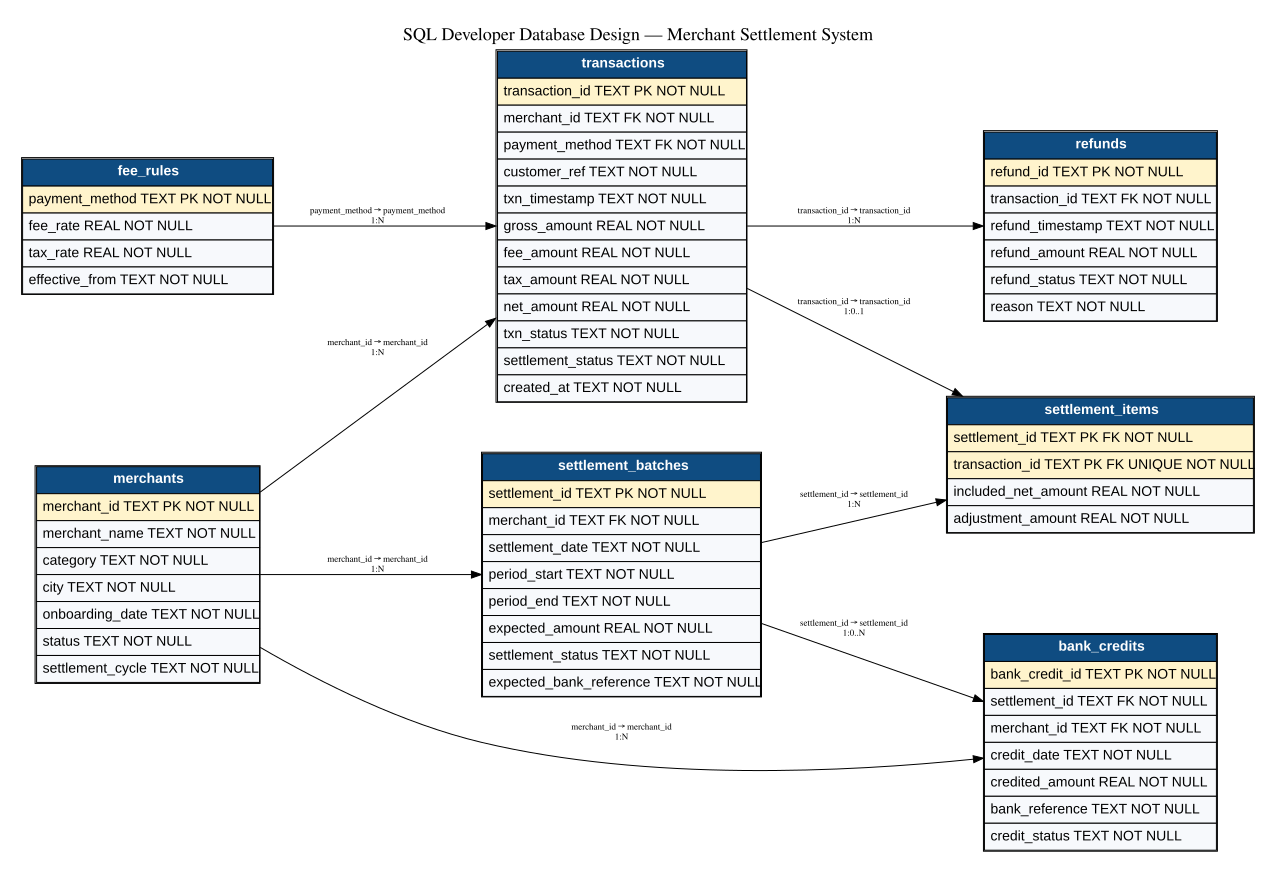

In [ ]:
developer_tables = {
    "merchants": [
        "merchant_id TEXT PK NOT NULL",
        "merchant_name TEXT NOT NULL",
        "category TEXT NOT NULL",
        "city TEXT NOT NULL",
        "onboarding_date TEXT NOT NULL",
        "status TEXT NOT NULL",
        "settlement_cycle TEXT NOT NULL",
    ],

    "fee_rules": [
        "payment_method TEXT PK NOT NULL",
        "fee_rate REAL NOT NULL",
        "tax_rate REAL NOT NULL",
        "effective_from TEXT NOT NULL",
    ],

    "transactions": [
        "transaction_id TEXT PK NOT NULL",
        "merchant_id TEXT FK NOT NULL",
        "payment_method TEXT FK NOT NULL",
        "customer_ref TEXT NOT NULL",
        "txn_timestamp TEXT NOT NULL",
        "gross_amount REAL NOT NULL",
        "fee_amount REAL NOT NULL",
        "tax_amount REAL NOT NULL",
        "net_amount REAL NOT NULL",
        "txn_status TEXT NOT NULL",
        "settlement_status TEXT NOT NULL",
        "created_at TEXT NOT NULL",
    ],

    "refunds": [
        "refund_id TEXT PK NOT NULL",
        "transaction_id TEXT FK NOT NULL",
        "refund_timestamp TEXT NOT NULL",
        "refund_amount REAL NOT NULL",
        "refund_status TEXT NOT NULL",
        "reason TEXT NOT NULL",
    ],

    "settlement_batches": [
        "settlement_id TEXT PK NOT NULL",
        "merchant_id TEXT FK NOT NULL",
        "settlement_date TEXT NOT NULL",
        "period_start TEXT NOT NULL",
        "period_end TEXT NOT NULL",
        "expected_amount REAL NOT NULL",
        "settlement_status TEXT NOT NULL",
        "expected_bank_reference TEXT NOT NULL",
    ],

    "settlement_items": [
        "settlement_id TEXT PK FK NOT NULL",
        "transaction_id TEXT PK FK UNIQUE NOT NULL",
        "included_net_amount REAL NOT NULL",
        "adjustment_amount REAL NOT NULL",
    ],

    "bank_credits": [
        "bank_credit_id TEXT PK NOT NULL",
        "settlement_id TEXT FK NOT NULL",
        "merchant_id TEXT FK NOT NULL",
        "credit_date TEXT NOT NULL",
        "credited_amount REAL NOT NULL",
        "bank_reference TEXT NOT NULL",
        "credit_status TEXT NOT NULL",
    ],
}

developer_relationships = [
    ("merchants", "merchant_id", "transactions", "merchant_id", "1:N"),
    ("fee_rules", "payment_method", "transactions", "payment_method", "1:N"),
    ("transactions", "transaction_id", "refunds", "transaction_id", "1:N"),
    ("merchants", "merchant_id", "settlement_batches", "merchant_id", "1:N"),
    ("settlement_batches", "settlement_id", "settlement_items", "settlement_id", "1:N"),
    ("transactions", "transaction_id", "settlement_items", "transaction_id", "1:0..1"),
    ("settlement_batches", "settlement_id", "bank_credits", "settlement_id", "1:0..N"),
    ("merchants", "merchant_id", "bank_credits", "merchant_id", "1:N"),
]

developer_er_diagram = validate_and_draw_er(developer_tables, developer_relationships)

### Expected Output — ER-1

After the design is complete, the cell should display:

- `✅ ER design check: Passed`
- Seven connected table boxes
- Primary-key fields highlighted
- One-to-many relationship arrows
- A composite primary key in `settlement_items`

**Hint:** Design parent/master tables first, then transactional tables, then bridge and settlement tables.

# 3. API Operations

The API server is already running. You are **not building the API**. Your work is to call the endpoints correctly using `requests`.

Run the next reference cell whenever you need to check the available endpoints.

In [ ]:
display(api_documentation)

,method,endpoint,purpose,expected_status
0,GET,/merchants,Read merchant records,200
1,GET,/transactions,Read transactions; supports filters and pagina...,200
2,GET,/transactions/{id},Read one transaction,200 / 404
3,POST,/transactions,Create one transaction,201 / 400 / 409
4,PUT,/transactions/{id},Replace the complete transaction,200 / 400 / 404
5,PATCH,/transactions/{id},Update supported fields; reject unknown fields...,200 / 400 / 404
6,DELETE,/transactions/{id},Delete one transaction,200 / 404
7,GET,/refunds,Read refund records,200
8,GET,/settlements,Read settlement batches,200
9,GET,/settlement_items,Read settlement-item mappings,200


## API-Q1 — Fetch Filtered Transactions

Fetch exactly five transactions where:

- `payment_method = UPI`
- `txn_status = SUCCESS`

Use a `GET` request and the `params` argument.

In [ ]:


api_q1_response = None

api_q1_response = requests.get(
    "http://127.0.0.1:8765/api/v1/transactions",
    params={
        "payment_method": "UPI",
        "txn_status": "SUCCESS",
        "limit": 5,
    },
    timeout=5,
)

validate_api_q1(api_q1_response)

,transaction_id,merchant_id,customer_ref,txn_timestamp,payment_method,gross_amount,fee_amount,tax_amount,net_amount,txn_status,settlement_status,created_at
0,TXN000001,M0042,CUST00470,2026-06-04 15:03:00,UPI,"2,144.31",10.72,1.93,"2,131.66",SUCCESS,PENDING,2026-06-04 15:03:00
1,TXN000002,M0027,CUST00580,2026-06-23 09:17:00,UPI,"6,224.33",31.12,5.60,"6,187.61",SUCCESS,SETTLED,2026-06-23 09:17:00
2,TXN000003,M0008,CUST00125,2026-06-03 23:48:00,UPI,"7,869.88",39.35,7.08,"7,823.45",SUCCESS,SETTLED,2026-06-03 23:48:00
3,TXN000007,M0024,CUST00233,2026-06-13 10:04:00,UPI,82.94,0.41,0.07,82.46,SUCCESS,PENDING,2026-06-13 10:04:00
4,TXN000011,M0027,CUST00492,2026-06-23 09:10:00,UPI,247.52,1.24,0.22,246.06,SUCCESS,SETTLED,2026-06-23 09:10:00


HTTP status: 200
Records returned: 5
Overall status: Passed


### Expected Output — API-Q1

- HTTP status: `200`
- Records returned: `5`
- Every displayed record has `payment_method = UPI`
- Every displayed record has `txn_status = SUCCESS`

**Hint:** The endpoint is `/transactions`; include `limit`, `payment_method`, and `txn_status` in `params`.

## API-Q2 — Create a Transaction with POST

Create the transaction provided in `new_transaction_payload`.

In [ ]:
# ✍️ SQL DEVELOPER WORKSPACE — API-Q2

remove_api_practice_record("TXN_API_POST_001")

new_transaction_payload = {
    "transaction_id": "TXN_API_POST_001",
    "merchant_id": "M0001",
    "customer_ref": "CUST_POST_001",
    "txn_timestamp": "2026-07-03 09:30:00",
    "payment_method": "UPI",
    "gross_amount": 800.00,
    "fee_amount": 4.00,
    "tax_amount": 0.72,
    "net_amount": 795.28,
    "txn_status": "PENDING",
    "settlement_status": "PENDING",
    "created_at": "2026-07-03 09:30:00",
}

api_q2_response = None

api_q2_response = requests.post(
    "http://127.0.0.1:8765/api/v1/transactions",
    json=new_transaction_payload,
    timeout=5,
)

validate_api_q2(api_q2_response)

,transaction_id,merchant_id,customer_ref,txn_timestamp,payment_method,gross_amount,fee_amount,tax_amount,net_amount,txn_status,settlement_status,created_at
0,TXN_API_POST_001,M0001,CUST_POST_001,2026-07-03 09:30:00,UPI,800.00,4.00,0.72,795.28,PENDING,PENDING,2026-07-03 09:30:00


Complete response-object check: Passed
HTTP status: 201
Overall status: Passed


### Expected Output — API-Q2

- HTTP status: `201`
- Created transaction ID: `TXN_API_POST_001`
- Overall status: `Passed`

**Hint:** Use `json=new_transaction_payload`.

## API-Q3 — Replace a Complete Transaction with PUT

The setup line creates `TXN_API_PUT_001`. Replace its complete content using `replacement_payload`.

In [ ]:
# ✍️ SQL DEVELOPER WORKSPACE — API-Q3

reset_api_practice_record("TXN_API_PUT_001")

replacement_payload = {
    "transaction_id": "TXN_API_PUT_001",
    "merchant_id": "M0002",
    "customer_ref": "CUST_REPLACED",
    "txn_timestamp": "2026-07-03 11:00:00",
    "payment_method": "CARD",
    "gross_amount": 1250.00,
    "fee_amount": 22.50,
    "tax_amount": 4.05,
    "net_amount": 1223.45,
    "txn_status": "PENDING",
    "settlement_status": "PENDING",
    "created_at": "2026-07-03 11:00:00",
}

api_q3_response = None

api_q3_response = requests.put(
    "http://127.0.0.1:8765/api/v1/transactions/TXN_API_PUT_001",
    json=replacement_payload,
    timeout=5,
)

validate_api_q3(api_q3_response)

,transaction_id,merchant_id,customer_ref,txn_timestamp,payment_method,gross_amount,fee_amount,tax_amount,net_amount,txn_status,settlement_status,created_at
0,TXN_API_PUT_001,M0002,CUST_REPLACED,2026-07-03 11:00:00,CARD,"1,250.00",22.50,4.05,"1,223.45",PENDING,PENDING,2026-07-03 11:00:00


Complete response-object check: Passed
HTTP status: 200
Overall status: Passed


### Expected Output — API-Q3

- HTTP status: `200`
- Payment method becomes `CARD`
- Gross amount becomes `1250.00`
- Customer reference becomes `CUST_REPLACED`

**Hint:** `PUT` uses the record-specific endpoint `/transactions/TXN_API_PUT_001`.

## API-Q4 — Update Selected Fields with PATCH

Update only these fields for `TXN_API_PATCH_001`:

- `txn_status` → `SUCCESS`
- `settlement_status` → `SETTLED`

In [ ]:
# ✍️ SQL DEVELOPER WORKSPACE — API-Q4

api_q4_baseline = reset_api_practice_record("TXN_API_PATCH_001")

patch_payload = {
    "txn_status": "SUCCESS",
    "settlement_status": "SETTLED",
}

api_q4_response = None

api_q4_response = requests.patch(
    "http://127.0.0.1:8765/api/v1/transactions/TXN_API_PATCH_001",
    json=patch_payload,
    timeout=5,
)

validate_api_q4(api_q4_response, api_q4_baseline, patch_payload)

,transaction_id,merchant_id,customer_ref,txn_timestamp,payment_method,gross_amount,fee_amount,tax_amount,net_amount,txn_status,settlement_status,created_at
0,TXN_API_PATCH_001,M0001,CUST_API_PRACTICE,2026-07-02 10:00:00,UPI,500.00,2.50,0.45,497.05,SUCCESS,SETTLED,2026-07-02 10:00:00


Fields changed from reset baseline: ['settlement_status', 'txn_status']
Only required Q4 fields changed: Passed
HTTP status: 200
Overall status: Passed


### Expected Output — API-Q4

- HTTP status: `200`
- `txn_status = SUCCESS`
- `settlement_status = SETTLED`

**Hint:** Unlike PUT, PATCH sends only the fields that need to change.

## API-Q5 — Multi-Request Delete Verification

Complete one operational sequence:

1. Fetch `TXN_API_DELETE_001`.
2. Delete it.
3. Fetch it again to confirm it no longer exists.

In [ ]:
# ✍️ SQL DEVELOPER WORKSPACE — API-Q5

reset_api_practice_record("TXN_API_DELETE_001")

api_q5_read_before = None
api_q5_delete = None
api_q5_read_after = None

record_url = "http://127.0.0.1:8765/api/v1/transactions/TXN_API_DELETE_001"

# TODO 1: GET the transaction
api_q5_read_before = requests.get(record_url, timeout=5)

# TODO 2: DELETE the transaction
api_q5_delete = requests.delete(record_url, timeout=5)

# TODO 3: GET the same transaction again
api_q5_read_after = requests.get(record_url, timeout=5)

validate_api_q5(api_q5_read_before, api_q5_delete, api_q5_read_after)

,request,http_status
0,GET before deletion,200
1,DELETE,200
2,GET after deletion,404


Overall status: Passed


### Expected Output — API-Q5

| Request | Expected HTTP status |
|---|---:|
| GET before deletion | 200 |
| DELETE | 200 |
| GET after deletion | 404 |

**Hint:** Use the same record-specific URL for all three requests.

# 4. SQL Developer Questions

From this point onward, write only SQL inside the triple-quoted strings.

## Rules

- Do not use Pandas to calculate SQL answers.
- Use the exact aliases requested.
- Do not change the question ID.
- A question is complete only when `Overall status: Passed` appears.
- Use the table explorer below before starting.

In [ ]:
schema_catalog = build_schema_catalog(conn)
display(schema_catalog)

TABLE_TO_PREVIEW = "transactions"   # Change this value to inspect another table.
display(run_query(f"SELECT * FROM {TABLE_TO_PREVIEW} LIMIT 5"))

,table_name,column_name,data_type,not_null,primary_key,default_value
0,api_ingestion_runs,run_id,INTEGER,False,True,None
1,api_ingestion_runs,endpoint,TEXT,True,False,None
2,api_ingestion_runs,started_at,TEXT,True,False,None
3,api_ingestion_runs,ended_at,TEXT,True,False,None
4,api_ingestion_runs,records_received,INTEGER,True,False,None
...,...,...,...,...,...,...
69,transactions,tax_amount,REAL,True,False,None
70,transactions,net_amount,REAL,True,False,None
71,transactions,txn_status,TEXT,True,False,None
72,transactions,settlement_status,TEXT,True,False,None


,transaction_id,merchant_id,customer_ref,txn_timestamp,payment_method,gross_amount,fee_amount,tax_amount,net_amount,txn_status,settlement_status,created_at
0,TXN000001,M0042,CUST00470,2026-06-04 15:03:00,UPI,"2,144.31",10.72,1.93,"2,131.66",SUCCESS,PENDING,2026-06-04 15:03:00
1,TXN000002,M0027,CUST00580,2026-06-23 09:17:00,UPI,"6,224.33",31.12,5.60,"6,187.61",SUCCESS,SETTLED,2026-06-23 09:17:00
2,TXN000003,M0008,CUST00125,2026-06-03 23:48:00,UPI,"7,869.88",39.35,7.08,"7,823.45",SUCCESS,SETTLED,2026-06-03 23:48:00
3,TXN000004,M0004,CUST00574,2026-06-23 04:07:00,NET_BANKING,114.44,1.14,0.21,113.09,SUCCESS,SETTLED,2026-06-23 04:07:00
4,TXN000005,M0004,CUST00098,2026-06-27 18:26:00,WALLET,951.36,11.42,2.06,937.88,SUCCESS,SETTLED,2026-06-27 18:26:00


## 4A. SQL Foundations and Multiple Tables

### Q1 — Largest Successful Payments

**Business requirement:** List the ten largest successful payments with merchant name, city, payment method, gross amount, net amount, and transaction timestamp.

**Tables to use:** `transactions`, `merchants`

**How to approach:**

- Join transactions with merchants.
- Filter successful transactions.
- Sort by gross amount descending.
- Return ten rows.

In [ ]:
# ✍️ SQL DEVELOPER WORKSPACE — Q1

q1_sql = r"""
SELECT
    t.transaction_id,
    m.merchant_name,
    m.city,
    t.payment_method,
    t.gross_amount,
    t.net_amount,
    t.txn_timestamp
FROM transactions t
JOIN merchants m ON t.merchant_id = m.merchant_id
WHERE t.txn_status = 'SUCCESS'
ORDER BY t.gross_amount DESC
LIMIT 10
"""

q1 = run_developer_query("Q1", q1_sql)

,transaction_id,merchant_name,city,payment_method,gross_amount,net_amount,txn_timestamp
0,TXN000501,Nova Mart 03,Pune,WALLET,"14,932.96","14,721.50",2026-06-21 14:28:00
1,TXN000186,Smart Services 09,Bengaluru,UPI,"14,881.79","14,793.99",2026-06-06 06:04:00
2,TXN001040,Green Works 42,Bengaluru,UPI,"14,869.65","14,781.92",2026-06-01 16:26:00
3,TXN000770,Metro Services 40,Chennai,CARD,"14,767.01","14,453.35",2026-06-09 17:58:00
4,TXN001015,Blue Hub 43,Bengaluru,NET_BANKING,"14,694.69","14,521.29",2026-06-06 12:02:00
5,TXN000763,Prime Store 28,Mumbai,WALLET,"14,637.30","14,430.03",2026-06-19 06:10:00
6,TXN000893,Green Hub 47,Pune,CARD,"14,597.71","14,305.20",2026-06-24 13:11:00
7,TXN001039,Green Foods 08,Chennai,WALLET,"14,546.67","14,340.69",2026-06-27 19:41:00
8,TXN000018,Urban Retail 46,Kolkata,WALLET,"14,503.58","14,298.21",2026-06-07 14:46:00
9,TXN000796,Blue Works 23,Hyderabad,NET_BANKING,"14,385.39","14,215.65",2026-06-21 19:36:00


Rows returned: 10
Column order check: Passed
Complete result-set check: Passed
Row-order rule: Required
Overall status: Passed


#### Expected Output — Q1

| Column | Requirement |
|---|---|
| `transaction_id` | Required output column |
| `merchant_name` | Required output column |
| `city` | Required output column |
| `payment_method` | Required output column |
| `gross_amount` | Required output column |
| `net_amount` | Required output column |
| `txn_timestamp` | Required output column |

**Expected row count:** `10`

**Expected first row after the required ordering:**

```text
| TXN000501 | Nova Mart 03 | Pune | WALLET | 14932.96 | 14721.50 | 2026-06-21 14:28:00 |
```

**Hint:** `JOIN`, `WHERE`, `ORDER BY ... DESC`, and `LIMIT`.

### Q2 — Aggregation, GROUP BY and HAVING

**Business requirement:** Find merchants with at least 15 successful payments and more than ₹50,000 in successful gross payment value.

**Tables to use:** `transactions`, `merchants`

**How to approach:**

- Filter successful rows.
- Group by merchant.
- Calculate counts and sums.
- Apply both conditions using HAVING.

In [ ]:
# ✍️ SQL DEVELOPER WORKSPACE — Q2

q2_sql = r"""
SELECT
    m.merchant_id,
    m.merchant_name,
    m.city,
    COUNT(t.transaction_id) AS successful_transactions,
    SUM(t.gross_amount) AS gross_payment_value,
    SUM(t.net_amount) AS net_payment_value
FROM merchants m
JOIN transactions t
    ON t.merchant_id = m.merchant_id
WHERE t.txn_status = 'SUCCESS'
GROUP BY
    m.merchant_id,
    m.merchant_name,
    m.city
HAVING
    COUNT(t.transaction_id) >= 15
    AND SUM(t.gross_amount) > 50000
"""

q2 = run_developer_query("Q2", q2_sql)

,merchant_id,merchant_name,city,successful_transactions,gross_payment_value,net_payment_value
0,M0002,Smart Hub 02,Bengaluru,21,"59,508.17","59,006.34"
1,M0004,Quick Retail 04,Pune,22,"64,859.91","64,122.85"
2,M0005,Smart Works 05,Bengaluru,18,"90,237.74","89,350.48"
3,M0006,Metro Retail 06,Kolkata,23,"61,567.05","61,129.31"
4,M0007,Nova Foods 07,Pune,21,"53,683.97","53,018.31"
5,M0008,Green Foods 08,Chennai,21,"69,706.21","68,931.95"
6,M0009,Smart Services 09,Bengaluru,26,"90,626.15","89,583.46"
7,M0010,Metro Store 10,Chennai,18,"95,483.50","94,689.88"
8,M0011,Urban Retail 11,Hyderabad,24,"89,001.13","87,782.86"
9,M0013,Nova Retail 13,Hyderabad,24,"65,946.94","65,351.51"


Rows returned: 34
Column order check: Passed
Complete result-set check: Passed
Row-order rule: Not enforced because the business requirement does not specify ordering
Overall status: Passed


#### Expected Output — Q2

| Column | Requirement |
|---|---|
| `merchant_id` | Required output column |
| `merchant_name` | Required output column |
| `city` | Required output column |
| `successful_transactions` | Required output column |
| `gross_payment_value` | Required output column |
| `net_payment_value` | Required output column |

**Expected row count:** `34`

**Example first row from the instructor output:**

```text
| M0017 | Shree Services 17 | Chennai | 30 | 120493.24 | 119304.22 |
```

**Hint:** `WHERE` filters rows; `HAVING` filters aggregated groups.

### Q3 — Settlement Reconciliation

**Business requirement:** Reconcile every settlement against bank credits and classify it as `MATCHED`, `MISSING`, or `MISMATCHED`.

**Tables to use:** `settlement_batches`, `merchants`, `bank_credits`

**How to approach:**

- Start from all settlement batches.
- Join merchant names.
- Left join bank credits.
- Aggregate credited amounts.
- Use a ₹0.02 tolerance.

In [ ]:
# ✍️ SQL DEVELOPER WORKSPACE — Q3

q3_sql = r"""
SELECT
    sb.settlement_id,
    m.merchant_name,
    sb.settlement_date,
    sb.expected_amount,
    COALESCE(SUM(bc.credited_amount), 0.00) AS credited_amount,
    ROUND(
        COALESCE(SUM(bc.credited_amount), 0.00) - sb.expected_amount,
        2
    ) AS variance,
    CASE
        WHEN COUNT(bc.bank_credit_id) = 0 THEN 'MISSING'
        WHEN ABS(
            COALESCE(SUM(bc.credited_amount), 0.00) - sb.expected_amount
        ) <= 0.02 THEN 'MATCHED'
        ELSE 'MISMATCHED'
    END AS reconciliation_status
FROM settlement_batches sb
JOIN merchants m
    ON sb.merchant_id = m.merchant_id
LEFT JOIN bank_credits bc
    ON bc.settlement_id = sb.settlement_id
GROUP BY
    sb.settlement_id,
    m.merchant_name,
    sb.settlement_date,
    sb.expected_amount
"""

q3 = run_developer_query("Q3", q3_sql)

,settlement_id,merchant_name,settlement_date,expected_amount,credited_amount,variance,reconciliation_status
0,SET00001,Green Retail 01,2026-06-09,"8,856.23","8,856.23",0.00,MATCHED
1,SET00002,Green Retail 01,2026-06-16,"7,645.33","7,645.33",0.00,MATCHED
2,SET00003,Green Retail 01,2026-06-23,"3,786.40","3,786.40",0.00,MATCHED
3,SET00004,Green Retail 01,2026-06-30,"8,690.27","8,690.27",0.00,MATCHED
4,SET00005,Green Retail 01,2026-07-02,202.56,202.56,0.00,MATCHED
5,SET00006,Smart Hub 02,2026-06-09,"3,205.58","3,205.58",0.00,MATCHED
6,SET00007,Smart Hub 02,2026-06-16,"2,261.73","2,261.73",0.00,MATCHED
7,SET00008,Smart Hub 02,2026-06-23,"5,399.87","4,706.18",-693.69,MISMATCHED
8,SET00009,Smart Hub 02,2026-06-30,"23,927.24","23,927.24",0.00,MATCHED
9,SET00010,Nova Mart 03,2026-06-08,"12,874.98","12,640.37",-234.61,MISMATCHED


Rows returned: 223
Column order check: Passed
Complete result-set check: Passed
Row-order rule: Not enforced because the business requirement does not specify ordering
Overall status: Passed


#### Expected Output — Q3

| Column | Requirement |
|---|---|
| `settlement_id` | Required output column |
| `merchant_name` | Required output column |
| `settlement_date` | Required output column |
| `expected_amount` | Required output column |
| `credited_amount` | Required output column |
| `variance` | Required output column |
| `reconciliation_status` | Required output column |

**Expected row count:** `223`

**Example first row from the instructor output:**

```text
| SET00212 | Smart Mart 48 | 2026-06-15 | 36525.08 | 0.00 | -36525.08 | MISSING |
```

**Hint:** `COALESCE`, `COUNT`, `SUM`, `CASE`, and `LEFT JOIN`.

### Q4 — Missing Bank Credits

**Business requirement:** Return settlement batches for which no bank-credit record exists.

**Tables to use:** `settlement_batches`, `merchants`, `bank_credits`

**How to approach:**

- Start with settlement batches.
- Left join bank credits.
- Keep rows where the bank-credit key is NULL.
- Sort by expected amount descending.

In [ ]:
q4_sql = r"""
SELECT
    sb.settlement_id,
    sb.merchant_id,
    m.merchant_name,
    sb.settlement_date,
    sb.expected_amount,
    sb.expected_bank_reference
FROM settlement_batches sb
JOIN merchants m
    ON sb.merchant_id = m.merchant_id
LEFT JOIN bank_credits bc
    ON bc.settlement_id = sb.settlement_id
WHERE bc.bank_credit_id IS NULL
ORDER BY sb.expected_amount DESC
"""

q4 = run_developer_query("Q4", q4_sql)

,settlement_id,merchant_id,merchant_name,settlement_date,expected_amount,expected_bank_reference
0,SET00212,M0048,Smart Mart 48,2026-06-15,"36,525.08",BNK0000212
1,SET00210,M0047,Green Hub 47,2026-06-30,"22,867.20",BNK0000210
2,SET00090,M0020,Quick Foods 20,2026-06-22,"21,591.99",BNK0000090
3,SET00125,M0028,Prime Store 28,2026-06-22,"19,429.13",BNK0000125
4,SET00124,M0028,Prime Store 28,2026-06-15,"17,491.26",BNK0000124
5,SET00150,M0034,Quick Retail 34,2026-06-15,"15,600.94",BNK0000150
6,SET00042,M0010,Metro Store 10,2026-06-09,"15,516.20",BNK0000042
7,SET00182,M0041,Shree Hub 41,2026-06-22,"11,983.39",BNK0000182
8,SET00159,M0036,Shree Hub 36,2026-06-15,"9,645.67",BNK0000159
9,SET00099,M0022,Prime Hub 22,2026-06-29,"8,263.71",BNK0000099


Rows returned: 16
Column order check: Passed
Complete result-set check: Passed
Row-order rule: Required
Overall status: Passed


#### Expected Output — Q4

| Column | Requirement |
|---|---|
| `settlement_id` | Required output column |
| `merchant_id` | Required output column |
| `merchant_name` | Required output column |
| `settlement_date` | Required output column |
| `expected_amount` | Required output column |
| `expected_bank_reference` | Required output column |

**Expected row count:** `16`

**Expected first row after the required ordering:**

```text
| SET00212 | M0048 | Smart Mart 48 | 2026-06-15 | 36525.08 | BNK0000212 |
```

**Hint:** `LEFT JOIN ... WHERE right_table.key IS NULL`.

## 4B. SQL Functions, Set Operations, Subqueries, and CTEs

### Q5 — Set Operations

**Business requirement:** Identify merchants that have both a completed refund and at least one open reconciliation exception.

**Tables to use:** `transactions`, `refunds`, `reconciliation_exceptions`, `merchants`

**How to approach:**

- Create a merchant set from completed refunds.
- Create another merchant set from open exceptions.
- Use INTERSECT.
- Return merchant details.

In [ ]:
q5_sql = r"""
SELECT
    m.merchant_id,
    m.merchant_name,
    m.city,
    m.category
FROM merchants m
WHERE m.merchant_id IN (
    SELECT DISTINCT t.merchant_id
    FROM refunds r
    JOIN transactions t
        ON t.transaction_id = r.transaction_id
    WHERE r.refund_status = 'COMPLETED'

    INTERSECT

    SELECT DISTINCT re.merchant_id
    FROM reconciliation_exceptions re
    WHERE re.resolution_status = 'OPEN'
)
ORDER BY m.merchant_id;
"""

q5 = run_developer_query("Q5", q5_sql)

,merchant_id,merchant_name,city,category
0,M0001,Green Retail 01,Pune,Fashion
1,M0002,Smart Hub 02,Bengaluru,Grocery
2,M0003,Nova Mart 03,Pune,Education
3,M0004,Quick Retail 04,Pune,Electronics
4,M0005,Smart Works 05,Bengaluru,Electronics
5,M0006,Metro Retail 06,Kolkata,Fashion
6,M0008,Green Foods 08,Chennai,Fashion
7,M0009,Smart Services 09,Bengaluru,Fashion
8,M0010,Metro Store 10,Chennai,Electronics
9,M0011,Urban Retail 11,Hyderabad,Grocery


Rows returned: 44
Column order check: Passed
Complete result-set check: Passed
Row-order rule: Not enforced because the business requirement does not specify ordering
Overall status: Passed


#### Expected Output — Q5

| Column | Requirement |
|---|---|
| `merchant_id` | Required output column |
| `merchant_name` | Required output column |
| `city` | Required output column |
| `category` | Required output column |

**Expected row count:** `44`

**Example first row from the instructor output:**

```text
| M0012 | Nova Hub 12 | Ahmedabad | Grocery |
```

**Hint:** `INTERSECT` can be used inside a `WHERE merchant_id IN (...)` subquery.

### Q6 — Essential SQL Functions

**Business requirement:** Create a merchant risk report using string functions, date calculations, null handling, conditional aggregation, and CASE.

**Tables to use:** `merchants`, `reconciliation_exceptions`

**How to approach:**

- Uppercase merchant names.
- Shorten category to 12 characters.
- Calculate merchant age as of 2026-07-05.
- Count open and critical exceptions.
- Assign a risk band.

In [ ]:
q6_sql = r"""
SELECT
    m.merchant_id,
    UPPER(m.merchant_name) AS merchant_name,
    m.city,
    SUBSTR(m.category, 1, 12) AS category_short,
    CAST(JULIANDAY('2026-07-05') - JULIANDAY(m.onboarding_date) AS INTEGER) AS merchant_age_days,
    COALESCE(oe.open_exceptions, 0) AS open_exceptions,
    COALESCE(ce.critical_exceptions, 0) AS critical_exceptions,
    CASE
        WHEN COALESCE(ce.critical_exceptions, 0) >= 1 THEN 'HIGH RISK'
        WHEN COALESCE(oe.open_exceptions, 0) >= 1 THEN 'MEDIUM RISK'
        ELSE 'LOW RISK'
    END AS risk_band
FROM merchants m
LEFT JOIN (
    SELECT
        merchant_id,
        COUNT(*) AS open_exceptions
    FROM reconciliation_exceptions
    WHERE resolution_status = 'OPEN'
      AND exception_type != 'FEE_RULE_MISMATCH'
    GROUP BY merchant_id
) oe
    ON oe.merchant_id = m.merchant_id
LEFT JOIN (
    SELECT
        merchant_id,
        COUNT(*) AS critical_exceptions
    FROM reconciliation_exceptions
    WHERE severity = 'CRITICAL'
    GROUP BY merchant_id
) ce
    ON ce.merchant_id = m.merchant_id
"""

q6 = run_developer_query("Q6", q6_sql)

print(q6[q6['merchant_id'] == 'M0041'].to_string(index=False))

,merchant_id,merchant_name,city,category_short,merchant_age_days,open_exceptions,critical_exceptions,risk_band
0,M0001,GREEN RETAIL 01,Pune,Fashion,446,6,0,MEDIUM RISK
1,M0002,SMART HUB 02,Bengaluru,Grocery,222,5,0,MEDIUM RISK
2,M0003,NOVA MART 03,Pune,Education,661,11,0,MEDIUM RISK
3,M0004,QUICK RETAIL 04,Pune,Electronics,265,6,0,MEDIUM RISK
4,M0005,SMART WORKS 05,Bengaluru,Electronics,661,7,0,MEDIUM RISK
5,M0006,METRO RETAIL 06,Kolkata,Fashion,816,8,1,HIGH RISK
6,M0007,NOVA FOODS 07,Pune,Travel,763,7,1,HIGH RISK
7,M0008,GREEN FOODS 08,Chennai,Fashion,771,2,0,MEDIUM RISK
8,M0009,SMART SERVICES 09,Bengaluru,Fashion,705,8,0,MEDIUM RISK
9,M0010,METRO STORE 10,Chennai,Electronics,656,7,1,HIGH RISK


Rows returned: 50
Column order check: Passed
Complete result-set check: Needs Review
Row-order rule: Not enforced because the business requirement does not specify ordering
Overall status: Needs Review
merchant_id merchant_name    city category_short  merchant_age_days  open_exceptions  critical_exceptions risk_band
      M0041  SHREE HUB 41 Chennai        Grocery                674                7                    2 HIGH RISK


#### Expected Output — Q6

| Column | Requirement |
|---|---|
| `merchant_id` | Required output column |
| `merchant_name` | Required output column |
| `city` | Required output column |
| `category_short` | Required output column |
| `merchant_age_days` | Required output column |
| `open_exceptions` | Required output column |
| `critical_exceptions` | Required output column |
| `risk_band` | Required output column |

**Expected row count:** `50`

**Example first row from the instructor output:**

```text
| M0041 | SHREE HUB 41 | Chennai | Grocery | 674 | 7 | 2 | HIGH RISK |
```

**Hint:** `UPPER`, `substr`, `julianday`, `CAST`, `COALESCE`, and `CASE`.

### Q7 — Subquery and Business Comparison

**Business requirement:** Find merchants whose successful gross payment value is greater than the average successful gross payment value across merchants.

**Tables to use:** `transactions`, `merchants`

**How to approach:**

- Calculate merchant totals.
- Calculate the average of those totals.
- Keep above-average merchants.
- Return the average as a comparison column.

In [ ]:
# ✍️ SQL DEVELOPER WORKSPACE — Q7

q7_sql = r"""
WITH merchant_totals AS (
    SELECT
        m.merchant_id,
        m.merchant_name,
        m.city,
        SUM(t.gross_amount) AS merchant_gpv
    FROM merchants m
    JOIN transactions t ON t.merchant_id = m.merchant_id
    WHERE t.txn_status = 'SUCCESS'
    GROUP BY m.merchant_id, m.merchant_name, m.city
)
SELECT
    merchant_id,
    merchant_name,
    city,
    merchant_gpv,
    (SELECT AVG(merchant_gpv) FROM merchant_totals) AS average_merchant_gpv
FROM merchant_totals
WHERE merchant_gpv > (SELECT AVG(merchant_gpv) FROM merchant_totals)
ORDER BY merchant_gpv DESC
"""

q7 = run_developer_query("Q7", q7_sql)

,merchant_id,merchant_name,city,merchant_gpv,average_merchant_gpv
0,M0017,Shree Services 17,Chennai,"120,493.24","62,870.23"
1,M0010,Metro Store 10,Chennai,"95,483.50","62,870.23"
2,M0009,Smart Services 09,Bengaluru,"90,626.15","62,870.23"
3,M0047,Green Hub 47,Pune,"90,398.18","62,870.23"
4,M0005,Smart Works 05,Bengaluru,"90,237.74","62,870.23"
5,M0011,Urban Retail 11,Hyderabad,"89,001.13","62,870.23"
6,M0019,Quick Foods 19,Hyderabad,"86,050.39","62,870.23"
7,M0046,Urban Retail 46,Kolkata,"84,463.17","62,870.23"
8,M0016,Prime Bazaar 16,Kolkata,"82,092.50","62,870.23"
9,M0035,Prime Works 35,Kolkata,"81,085.79","62,870.23"


Rows returned: 27
Column order check: Passed
Complete result-set check: Passed
Row-order rule: Not enforced because the business requirement does not specify ordering
Overall status: Passed


#### Expected Output — Q7

| Column | Requirement |
|---|---|
| `merchant_id` | Required output column |
| `merchant_name` | Required output column |
| `city` | Required output column |
| `merchant_gpv` | Required output column |
| `average_merchant_gpv` | Required output column |

**Expected row count:** `27`

**Example first row from the instructor output:**

```text
| M0017 | Shree Services 17 | Chennai | 120493.24 | 62870.23 |
```

**Hint:** Use a merchant-total CTE and a scalar average subquery.

### Q8 — Multi-Stage CTE

**Business requirement:** Recalculate every settlement from settlement items and compare it with the settlement-engine amount and bank-credited amount.

**Tables to use:** `settlement_items`, `settlement_batches`, `bank_credits`, `merchants`

**How to approach:**

- Aggregate item values.
- Aggregate bank credits.
- Combine both with settlement batches.
- Calculate engine and bank variances.
- Keep variances above ₹0.02.

In [ ]:
q8_sql = r"""
WITH item_totals AS (
    SELECT
        settlement_id,
        SUM(included_net_amount + adjustment_amount) AS calculated_from_items
    FROM settlement_items
    GROUP BY settlement_id
),
bank_totals AS (
    SELECT
        settlement_id,
        SUM(credited_amount) AS credited_by_bank
    FROM bank_credits
    GROUP BY settlement_id
)
SELECT
    sb.settlement_id,
    m.merchant_name,
    sb.expected_amount AS engine_amount,
    COALESCE(it.calculated_from_items, 0.00) AS calculated_from_items,
    COALESCE(bt.credited_by_bank, 0.00) AS credited_by_bank,
    ROUND(COALESCE(it.calculated_from_items, 0.00) - sb.expected_amount, 2) AS engine_variance,
    ROUND(COALESCE(bt.credited_by_bank, 0.00) - sb.expected_amount, 2) AS bank_variance
FROM settlement_batches sb
JOIN merchants m ON m.merchant_id = sb.merchant_id
LEFT JOIN item_totals it ON it.settlement_id = sb.settlement_id
LEFT JOIN bank_totals bt ON bt.settlement_id = sb.settlement_id
WHERE ABS(ROUND(COALESCE(it.calculated_from_items, 0.00) - sb.expected_amount, 2)) > 0.02
   OR ABS(ROUND(COALESCE(bt.credited_by_bank, 0.00) - sb.expected_amount, 2)) > 0.02
"""

q8 = run_developer_query("Q8", q8_sql)

,settlement_id,merchant_name,engine_amount,calculated_from_items,credited_by_bank,engine_variance,bank_variance
0,SET00001,Green Retail 01,"8,856.23","8,640.18","8,856.23",-216.05,0.00
1,SET00005,Green Retail 01,202.56,134.51,202.56,-68.05,0.00
2,SET00006,Smart Hub 02,"3,205.58","2,966.11","3,205.58",-239.47,0.00
3,SET00007,Smart Hub 02,"2,261.73",696.23,"2,261.73","-1,565.50",0.00
4,SET00008,Smart Hub 02,"5,399.87","5,399.87","4,706.18",0.00,-693.69
5,SET00010,Nova Mart 03,"12,874.98","12,874.98","12,640.37",0.00,-234.61
6,SET00012,Nova Mart 03,"15,075.24","15,010.92","15,075.24",-64.32,0.00
7,SET00013,Nova Mart 03,0.00,-136.40,0.00,-136.40,0.00
8,SET00014,Quick Retail 04,"8,656.12","6,215.03","8,656.12","-2,441.09",0.00
9,SET00022,Metro Retail 06,"5,548.60","5,548.60","4,950.46",0.00,-598.14


Rows returned: 101
Column order check: Passed
Complete result-set check: Needs Review
Row-order rule: Not enforced because the business requirement does not specify ordering
Overall status: Needs Review
Expected rows: 54 | Actual rows: 101


#### Expected Output — Q8

| Column | Requirement |
|---|---|
| `settlement_id` | Required output column |
| `merchant_name` | Required output column |
| `engine_amount` | Required output column |
| `calculated_from_items` | Required output column |
| `credited_by_bank` | Required output column |
| `engine_variance` | Required output column |
| `bank_variance` | Required output column |

**Expected row count:** `54`

**Example first row from the instructor output:**

```text
| SET00212 | Smart Mart 48 | 36525.08 | 36525.08 | 0.00 | 0.00 | -36525.08 |
```

**Hint:** Use separate CTEs for item totals and bank totals.

## 4C. Window Functions

### Q9 — RANK and PARTITION BY

**Business requirement:** Rank merchants by successful net payment value within each city.

**Tables to use:** `merchants`, `transactions`

**How to approach:**

- Aggregate successful net value per merchant.
- Partition ranking by city.
- Rank highest to lowest.
- Order by city, rank, and merchant ID.

In [ ]:
q9_sql = r"""
WITH merchant_net_values AS (
    SELECT
        m.merchant_id,
        m.merchant_name,
        m.city,
        SUM(t.net_amount) AS total_net_value
    FROM merchants m
    JOIN transactions t ON m.merchant_id = t.merchant_id
    WHERE t.txn_status = 'SUCCESS'
    GROUP BY m.merchant_id, m.merchant_name, m.city
)
SELECT
    city,
    merchant_id,
    merchant_name,
    total_net_value,
    RANK() OVER (PARTITION BY city ORDER BY total_net_value DESC) AS city_rank
FROM merchant_net_values
ORDER BY
    city,
    city_rank,
    merchant_id;
"""

q9 = run_developer_query("Q9", q9_sql)

,city,merchant_id,merchant_name,total_net_value,city_rank
0,Ahmedabad,M0012,Nova Hub 12,"46,368.13",1
1,Ahmedabad,M0049,Metro Bazaar 49,"34,811.11",2
2,Ahmedabad,M0034,Quick Retail 34,"32,152.69",3
3,Ahmedabad,M0014,Smart Services 14,"20,038.87",4
4,Bengaluru,M0009,Smart Services 09,"89,583.46",1
5,Bengaluru,M0005,Smart Works 05,"89,350.48",2
6,Bengaluru,M0042,Green Works 42,"78,349.68",3
7,Bengaluru,M0043,Blue Hub 43,"69,238.21",4
8,Bengaluru,M0032,Shree Works 32,"67,278.58",5
9,Bengaluru,M0030,Shree Store 30,"63,931.78",6


Rows returned: 50
Column order check: Passed
Complete result-set check: Passed
Row-order rule: Required
Overall status: Passed


#### Expected Output — Q9

| Column | Requirement |
|---|---|
| `city` | Required output column |
| `merchant_id` | Required output column |
| `merchant_name` | Required output column |
| `total_net_value` | Required output column |
| `city_rank` | Required output column |

**Expected row count:** `50`

**Expected first row after the required ordering:**

```text
| Ahmedabad | M0012 | Nova Hub 12 | 46368.13 | 1 |
```

**Hint:** `RANK() OVER (PARTITION BY city ORDER BY total_net_value DESC)`.

### Q10 — Running Total and Moving Average

**Business requirement:** Calculate daily successful transaction count, daily net value, cumulative net value, and seven-day moving average for June 2026.

**Tables to use:** `transactions`

**How to approach:**

- Filter successful transactions.
- Convert each net amount into integer paise before aggregation.
- Aggregate the successful transaction count and net value by date.
- Calculate the cumulative total over the daily paise values.
- Calculate the seven-day moving average over the daily paise values.
- Convert the final monetary outputs back into rupees.
- Order the result chronologically by txn_date.

In [ ]:
q10_sql = r"""
WITH daily_paise_summary AS (
    SELECT
        DATE(txn_timestamp) AS txn_date,
        COUNT(*) AS successful_transactions,
        SUM(CAST(ROUND(net_amount * 100) AS INTEGER)) AS daily_net_value_paise
    FROM transactions
    WHERE
        txn_status = 'SUCCESS' AND STRFTIME('%Y-%m', txn_timestamp) = '2026-06'
    GROUP BY
        txn_date
)
SELECT
    txn_date,
    successful_transactions,
    ROUND(daily_paise_summary.daily_net_value_paise / 100.0, 2) AS daily_net_value,
    ROUND(SUM(daily_paise_summary.daily_net_value_paise) OVER (ORDER BY daily_paise_summary.txn_date ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) / 100.0, 2) AS cumulative_net_value,
    ROUND(AVG(daily_paise_summary.daily_net_value_paise) OVER (ORDER BY daily_paise_summary.txn_date ROWS BETWEEN 6 PRECEDING AND CURRENT ROW) / 100.0, 2) AS seven_day_moving_average
FROM
    daily_paise_summary
ORDER BY
    txn_date;
"""

q10 = run_developer_query("Q10", q10_sql)

,txn_date,successful_transactions,daily_net_value,cumulative_net_value,seven_day_moving_average
0,2026-06-01,52,"134,598.06","134,598.06","134,598.06"
1,2026-06-02,19,"57,424.93","192,022.99","96,011.49"
2,2026-06-03,37,"90,659.84","282,682.83","94,227.61"
3,2026-06-04,32,"84,741.79","367,424.62","91,856.15"
4,2026-06-05,47,"128,023.59","495,448.21","99,089.64"
5,2026-06-06,28,"76,954.85","572,403.06","95,400.51"
6,2026-06-07,28,"68,860.78","641,263.84","91,609.12"
7,2026-06-08,41,"133,968.82","775,232.66","91,519.23"
8,2026-06-09,38,"129,173.15","904,405.81","101,768.97"
9,2026-06-10,40,"173,756.56","1,078,162.37","113,639.93"


Rows returned: 30
Column order check: Passed
Complete result-set check: Needs Review
Row-order rule: Required
Overall status: Needs Review


#### Expected Output — Q10

| Column | Requirement |
|---|---|
| `txn_date` | Required output column |
| `successful_transactions` | Required output column |
| `daily_net_value` | Required output column |
| `cumulative_net_value` | Required output column |
| `seven_day_moving_average` | Required output column |

**Expected row count:** `30`

**Expected first row after the required ordering:**

```text
| 2026-06-01 | 52 | 134598.06 | 134598.06 | 134598.06 |
```

**Hint:** Use `ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW` and `ROWS BETWEEN 6 PRECEDING AND CURRENT ROW`. Also, Convert net_amount into integer paise before applying the
running SUM and seven-row AVG. This prevents SQLite floating-point
rounding differences across runtime environments..

### Q11 — LAG Day-over-Day Comparison

**Business requirement:** Compare each day’s successful net payment value with the previous day and calculate absolute and percentage change.

**Tables to use:** `transactions`

**How to approach:**

- Create daily successful value.
- Use LAG.
- Calculate absolute difference.
- Calculate percentage difference safely.

In [ ]:
q11_sql = r"""
WITH daily_net_summary AS (
    SELECT
        DATE(txn_timestamp) AS txn_date,
        SUM(net_amount) AS daily_net_value
    FROM transactions
    WHERE
        txn_status = 'SUCCESS' AND STRFTIME('%Y-%m', txn_timestamp) = '2026-06'
    GROUP BY
        txn_date
)
SELECT
    txn_date,
    daily_net_value,
    LAG(daily_net_value, 1) OVER (ORDER BY txn_date) AS previous_day_value,
    daily_net_value - LAG(daily_net_value, 1) OVER (ORDER BY txn_date) AS absolute_change,
    ROUND((daily_net_value - LAG(daily_net_value, 1) OVER (ORDER BY txn_date)) * 100.0 / NULLIF(LAG(daily_net_value, 1) OVER (ORDER BY txn_date), 0), 2) AS percentage_change
FROM
    daily_net_summary
ORDER BY
    txn_date;
"""
q11 = run_developer_query("Q11", q11_sql)

,txn_date,daily_net_value,previous_day_value,absolute_change,percentage_change
0,2026-06-01,"134,598.06",NaN,NaN,NaN
1,2026-06-02,"57,424.93","134,598.06","-77,173.13",-57.34
2,2026-06-03,"90,659.84","57,424.93","33,234.91",57.88
3,2026-06-04,"84,741.79","90,659.84","-5,918.05",-6.53
4,2026-06-05,"128,023.59","84,741.79","43,281.80",51.07
5,2026-06-06,"76,954.85","128,023.59","-51,068.74",-39.89
6,2026-06-07,"68,860.78","76,954.85","-8,094.07",-10.52
7,2026-06-08,"133,968.82","68,860.78","65,108.04",94.55
8,2026-06-09,"129,173.15","133,968.82","-4,795.67",-3.58
9,2026-06-10,"173,756.56","129,173.15","44,583.41",34.51


Rows returned: 30
Column order check: Passed
Complete result-set check: Passed
Row-order rule: Required
Overall status: Passed


#### Expected Output — Q11

| Column | Requirement |
|---|---|
| `txn_date` | Required output column |
| `daily_net_value` | Required output column |
| `previous_day_value` | Required output column |
| `absolute_change` | Required output column |
| `percentage_change` | Required output column |

**Expected row count:** `30`

**Expected first row after the required ordering:**

```text
| 2026-06-01 | 134598.06 | NULL | NULL | NULL |
```

**Display note:** SQLite `NULL` values are displayed as `NaN` when the result is loaded into a pandas DataFrame.

**Hint:** Use `NULLIF(previous_day_value, 0)` to prevent division by zero.

### Q12 — First and Latest Records

**Business requirement:** Return the first and latest successful transaction for every merchant.

**Tables to use:** `transactions`, `merchants`

**How to approach:**

- Rank records ascending and descending within each merchant.
- Use conditional aggregation.
- Keep all merchants.

In [ ]:
q12_sql = r"""
WITH RankedTransactions AS (
    SELECT
        t.merchant_id,
        t.transaction_id,
        t.txn_timestamp,
        ROW_NUMBER() OVER (PARTITION BY t.merchant_id ORDER BY t.txn_timestamp ASC) AS rn_asc,
        ROW_NUMBER() OVER (PARTITION BY t.merchant_id ORDER BY t.txn_timestamp DESC) AS rn_desc
    FROM
        transactions t
    WHERE
        t.txn_status = 'SUCCESS'
)
SELECT
    m.merchant_id,
    m.merchant_name,
    MAX(CASE WHEN rt.rn_asc = 1 THEN rt.transaction_id END) AS first_transaction_id,
    MAX(CASE WHEN rt.rn_asc = 1 THEN rt.txn_timestamp END) AS first_transaction_time,
    MAX(CASE WHEN rt.rn_desc = 1 THEN rt.transaction_id END) AS latest_transaction_id,
    MAX(CASE WHEN rt.rn_desc = 1 THEN rt.txn_timestamp END) AS latest_transaction_time
FROM
    merchants m
JOIN
    RankedTransactions rt ON m.merchant_id = rt.merchant_id
GROUP BY
    m.merchant_id, m.merchant_name
ORDER BY
    m.merchant_id;
"""

q12 = run_developer_query("Q12", q12_sql)

,merchant_id,merchant_name,first_transaction_id,first_transaction_time,latest_transaction_id,latest_transaction_time
0,M0001,Green Retail 01,TXN000508,2026-06-02 21:16:00,TXN000348,2026-06-30 01:09:00
1,M0002,Smart Hub 02,TXN000168,2026-06-01 06:19:00,TXN000423,2026-06-28 06:39:00
2,M0003,Nova Mart 03,TXN001142,2026-06-01 17:25:00,TXN001081,2026-06-30 12:04:00
3,M0004,Quick Retail 04,TXN000036,2026-06-01 13:59:00,TXN000005,2026-06-27 18:26:00
4,M0005,Smart Works 05,TXN000519,2026-06-02 03:55:00,TXN000898,2026-06-28 02:27:00
5,M0006,Metro Retail 06,TXN000391,2026-06-03 10:52:00,TXN000847,2026-06-30 22:04:00
6,M0007,Nova Foods 07,TXN000919,2026-06-01 05:41:00,TXN000232,2026-06-30 16:54:00
7,M0008,Green Foods 08,TXN000812,2026-06-01 11:50:00,TXN000355,2026-06-29 21:37:00
8,M0009,Smart Services 09,TXN000340,2026-06-01 12:20:00,TXN001186,2026-06-29 21:33:00
9,M0010,Metro Store 10,TXN000021,2026-06-01 00:31:00,TXN000212,2026-06-29 03:20:00


Rows returned: 50
Column order check: Passed
Complete result-set check: Passed
Row-order rule: Not enforced because the business requirement does not specify ordering
Overall status: Passed


#### Expected Output — Q12

| Column | Requirement |
|---|---|
| `merchant_id` | Required output column |
| `merchant_name` | Required output column |
| `first_transaction_id` | Required output column |
| `first_transaction_time` | Required output column |
| `latest_transaction_id` | Required output column |
| `latest_transaction_time` | Required output column |

**Expected row count:** `50`

**Example first row from the instructor output:**

```text
| M0001 | Green Retail 01 | TXN000508 | 2026-06-02 21:16:00 | TXN000348 | 2026-06-30 01:09:00 |
```

**Hint:** Use two `ROW_NUMBER()` windows and `MAX(CASE WHEN ...)`.

### Q13 — Top Three Exception Ranks per City

**Business requirement:** Return merchants in the top three open-exception ranks within each city. Tied merchants should share the same rank.

**Tables to use:** `merchants`, `reconciliation_exceptions`

**How to approach:**

- Aggregate open and critical exception counts.
- Rank inside each city.
- Use DENSE_RANK for ties.
- Keep ranks 1 to 3.

In [ ]:
q13_sql = r"""
WITH MerchantExceptions AS (
    SELECT
        m.merchant_id,
        m.merchant_name,
        m.city,
        COUNT(re.exception_id) AS exception_count,
        COUNT(CASE WHEN re.severity = 'CRITICAL' THEN re.exception_id END) AS critical_count
    FROM merchants m
    LEFT JOIN reconciliation_exceptions re ON m.merchant_id = re.merchant_id
    WHERE re.resolution_status = 'OPEN'
    GROUP BY m.merchant_id, m.merchant_name, m.city
),
RankedMerchantExceptions AS (
    SELECT
        merchant_id,
        merchant_name,
        city,
        exception_count,
        critical_count,
        DENSE_RANK() OVER (PARTITION BY city ORDER BY exception_count DESC, critical_count DESC) AS exception_rank
    FROM MerchantExceptions
)
SELECT
    city,
    merchant_id,
    merchant_name,
    exception_count,
    critical_count,
    exception_rank
FROM RankedMerchantExceptions
WHERE exception_rank <= 3
ORDER BY city, exception_rank, merchant_id;
"""

q13 = run_developer_query("Q13", q13_sql)

,city,merchant_id,merchant_name,exception_count,critical_count,exception_rank
0,Ahmedabad,M0014,Smart Services 14,7,0,1
1,Ahmedabad,M0012,Nova Hub 12,6,0,2
2,Ahmedabad,M0034,Quick Retail 34,5,1,3
3,Bengaluru,M0032,Shree Works 32,10,1,1
4,Bengaluru,M0043,Blue Hub 43,10,1,1
5,Bengaluru,M0009,Smart Services 09,10,0,2
6,Bengaluru,M0005,Smart Works 05,7,0,3
7,Chennai,M0026,Quick Works 26,13,0,1
8,Chennai,M0010,Metro Store 10,9,1,2
9,Chennai,M0017,Shree Services 17,9,0,3


Rows returned: 26
Column order check: Passed
Complete result-set check: Needs Review
Row-order rule: Not enforced because the business requirement does not specify ordering
Overall status: Needs Review
Expected rows: 30 | Actual rows: 26


#### Expected Output — Q13

| Column | Requirement |
|---|---|
| `city` | Required output column |
| `merchant_id` | Required output column |
| `merchant_name` | Required output column |
| `exception_count` | Required output column |
| `critical_count` | Required output column |
| `exception_rank` | Required output column |

**Expected row count:** `30`

**Example first row from the instructor output:**

```text
| Ahmedabad | M0014 | Smart Services 14 | 7 | 0 | 1 |
```

**Hint:** Use `DENSE_RANK()` because ties should share a rank.

# 5. Transaction Management

Use SQL transaction-control statements. Each task runs against a separate SQLite connection and can be safely rerun.

## T1 — Commit an Approved Manual Adjustment

Insert one ledger entry with:

- `ledger_entry_id = LED-DEVELOPER-COMMIT`
- `merchant_id = M0001`
- `entry_type = MANUAL_ADJUSTMENT`
- `amount = 250`
- `entry_timestamp = 2026-07-05 10:00:00`
- Description: `Approved manual credit`

The row must remain in the database after the script finishes.

In [ ]:
t1_sql = r"""
BEGIN;

INSERT INTO merchant_ledger (
    ledger_entry_id, merchant_id, transaction_id, settlement_id,
    entry_type, amount, entry_timestamp, description
)
VALUES (
    'LED-DEVELOPER-COMMIT', 'M0001', NULL, NULL,
    'MANUAL_ADJUSTMENT', 250.0, '2026-07-05 10:00:00', 'Approved manual credit'
);

COMMIT;
"""

t1_result = run_transaction_task(
    "T1",
    t1_sql,
    ledger_entry_id="LED-DEVELOPER-COMMIT",
    should_exist=True,
)

,ledger_entry_id,merchant_id,transaction_id,settlement_id,entry_type,amount,entry_timestamp,description
0,LED-DEVELOPER-COMMIT,M0001,None,None,MANUAL_ADJUSTMENT,250.00,2026-07-05 10:00:00,Approved manual credit


BEGIN / INSERT / final-control sequence: Passed
Exact inserted field values: Passed
Final persistence state: Passed
Overall status: Passed


### Expected Output — T1

- `BEGIN / INSERT / final-control sequence: Passed`
- `Exact inserted field values: Passed`
- `Final persistence state: Passed`
- One ledger row is displayed.
- `Overall status: Passed`

**Hint:** Use `BEGIN;`, one `INSERT`, and `COMMIT;`.

## T2 — Roll Back an Unapproved Adjustment

Insert a temporary ledger entry with:

- `ledger_entry_id = LED-DEVELOPER-ROLLBACK`
- `merchant_id = M0002`
- `entry_type = MANUAL_ADJUSTMENT`
- `amount = -100`
- `entry_timestamp = 2026-07-05 11:00:00`
- Description: `Unapproved temporary debit`

Then roll back the transaction so the row does **not** remain in the database.

In [ ]:
t2_sql = r"""
BEGIN;

INSERT INTO merchant_ledger (
    ledger_entry_id, merchant_id, transaction_id, settlement_id,
    entry_type, amount, entry_timestamp, description
)
VALUES (
    'LED-DEVELOPER-ROLLBACK', 'M0002', NULL, NULL,
    'MANUAL_ADJUSTMENT', -100.0, '2026-07-05 11:00:00', 'Unapproved temporary debit'
);

ROLLBACK;
"""

t2_result = run_transaction_task(
    "T2",
    t2_sql,
    ledger_entry_id="LED-DEVELOPER-ROLLBACK",
    should_exist=False,
)

,ledger_entry_id,merchant_id,transaction_id,settlement_id,entry_type,amount,entry_timestamp,description


BEGIN / INSERT / final-control sequence: Passed
Exact inserted field values: Passed
Final persistence state: Passed
Overall status: Passed


### Expected Output — T2

- `BEGIN / INSERT / final-control sequence: Passed`
- `Exact inserted field values: Passed`
- `Final persistence state: Passed`
- No ledger row remains after rollback.
- `Overall status: Passed`

**Hint:** Replace `COMMIT` with `ROLLBACK`.

# 6. Workflow Automation

You are not required to configure a live cron service in Colab. Instead, you will:

1. Design the automated process.
2. Generate its architecture diagram.
3. Write one SQL report query.
4. Write cron expressions for realistic schedules.

## AUTO-FLOW — Design the Daily Automation Process

Create exactly seven ordered steps for this workflow:

1. A scheduler starts the process.
2. The API is called.
3. The response is validated.
4. Raw JSON is saved.
5. Validated data is loaded into SQLite.
6. Reconciliation exceptions are recalculated, and the open-exception SQL report is generated.
7. The result and run status are logged.

Write each step in your own clear words. The notebook will convert your answer into a flowchart.

✅ Overall status: Passed


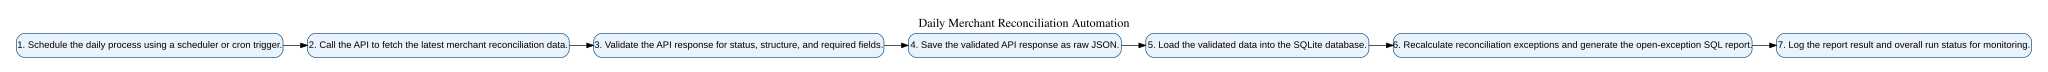

In [ ]:
automation_steps = [
    "Schedule the daily process using a scheduler or cron trigger.",
    "Call the API to fetch the latest merchant reconciliation data.",
    "Validate the API response for status, structure, and required fields.",
    "Save the validated API response as raw JSON.",
    "Load the validated data into the SQLite database.",
    "Recalculate reconciliation exceptions and generate the open-exception SQL report.",
    "Log the report result and overall run status for monitoring."
]

automation_flowchart = validate_sequence(
    "AUTO-FLOW",
    automation_steps,
    expected_keyword_groups=[
        ["schedule", "cron", "trigger"],
        ["api", "fetch", "request"],
        ["validate", "status", "schema"],
        ["raw", "json", "save"],
        ["sqlite", "database", "load"],
        ["detect", "recalculate", "refresh", "recompute", "rebuild"],
        ["log", "monitor"],
    ],
    title="Daily Merchant Reconciliation Automation",
)

### Expected Output — AUTO-FLOW

- `✅ Overall status: Passed`
- A left-to-right seven-step architecture diagram
- The diagram starts with scheduling and ends with logging/monitoring

**Hint:** Each step must contain the main action keyword described in the requirement.

## AUTO-REPORT — Write the Automated Exception Report Query

Create a report for all open reconciliation exceptions.

Return:

- `exception_type`
- `severity`
- `exception_count`
- `total_expected_value`
- `total_actual_value`

Group by exception type and severity. Order by exception count descending and exception type ascending.

In [ ]:
auto_report_sql = r"""
SELECT
    exception_type,
    severity,
    COUNT(exception_id) AS exception_count,
    ROUND(SUM(expected_value), 2) AS total_expected_value,
    ROUND(SUM(actual_value), 2) AS total_actual_value
FROM
    reconciliation_exceptions
WHERE
    resolution_status = 'OPEN'
GROUP BY
    exception_type,
    severity
ORDER BY
    exception_count DESC,
    exception_type ASC;

"""

auto_report = run_developer_query("AUTO-REPORT", auto_report_sql)

,exception_type,severity,exception_count,total_expected_value,total_actual_value
0,OVERDUE_UNSETTLED_TRANSACTION,HIGH,250,341.00,"4,841.00"
1,FEE_RULE_MISMATCH,MEDIUM,28,945.73,990.79
2,BANK_AMOUNT_MISMATCH,HIGH,21,"200,594.46","215,731.74"
3,MISSING_BANK_CREDIT,CRITICAL,16,"205,043.26",NaN
4,LATE_BANK_CREDIT,MEDIUM,13,26.00,52.00
5,DUPLICATE_BANK_REFERENCE,CRITICAL,4,4.00,8.00


Rows returned: 6
Column order check: Passed
Complete result-set check: Needs Review
Row-order rule: Required
Overall status: Needs Review


### Expected Output — AUTO-REPORT

- Columns: `exception_type`, `severity`, `exception_count`, `total_expected_value`, `total_actual_value`
- Expected row count: `6`
- First row:
  - `OVERDUE_UNSETTLED_TRANSACTION`
  - `HIGH`
  - `250`

**Hint:** Use `COUNT`, `SUM`, `COALESCE`, `ROUND`, `GROUP BY`, and `ORDER BY`.

## AUTO-CRON — Write Cron Expressions

Complete all four schedules:

1. Run daily at **8 AM, 12 PM, and 4 PM**.
2. Run every **weekday at 5 PM**.
3. Run **every day at midnight**.
4. Run **every Sunday at 2 AM**.

Only write the five-field cron expression, not the command path.

In [ ]:
# ✍️ SQL DEVELOPER WORKSPACE — AUTO-CRON

cron_answers = {
    "three_times_daily": "0 8,12,16 * * *",
    "weekday_5pm": "0 17 * * 1-5",
    "daily_midnight": "0 0 * * *",
    "sunday_2am": "0 2 * * 0",
}

cron_result = validate_cron_answers(cron_answers)

,scenario,required_schedule,your_expression,status
0,three_times_daily,"Daily at 8 AM, 12 PM, and 4 PM","0 8,12,16 * * *",Passed
1,weekday_5pm,Every weekday at 5 PM,0 17 * * 1-5,Passed
2,daily_midnight,Every day at midnight,0 0 * * *,Passed
3,sunday_2am,Every Sunday at 2 AM,0 2 * * 0,Passed


Overall status: Passed


### Expected Output — AUTO-CRON

A four-row validation table where every scenario shows `Passed`.

**Cron field order:**

```text
minute hour day-of-month month day-of-week
```

**Example only:** `30 9 * * 1-5` means 9:30 AM from Monday to Friday.

# 7. Engineering Practices

No Git command-line work is required here. Instead, demonstrate that you understand the correct professional workflow by arranging the steps. The notebook will generate diagrams from your answers.

## ENG-GIT — Git Collaboration Workflow

Write exactly eight ordered steps covering:

1. Read the task.
2. Create a feature branch.
3. Write the SQL change.
4. Test it.
5. Commit it.
6. Push the branch.
7. Open a pull request and complete review.
8. Merge after approval.

✅ Overall status: Passed


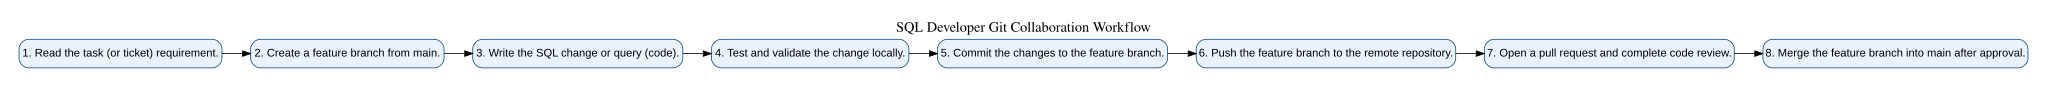

In [ ]:
# ✍️ SQL DEVELOPER WORKSPACE — ENG-GIT

git_workflow_steps = [
    "Read the task (or ticket) requirement.",
    "Create a feature branch from main.",
    "Write the SQL change or query (code).",
    "Test and validate the change locally.",
    "Commit the changes to the feature branch.",
    "Push the feature branch to the remote repository.",
    "Open a pull request and complete code review.",
    "Merge the feature branch into main after approval."
]

git_workflow_diagram = validate_sequence(
    "ENG-GIT",
    git_workflow_steps,
    expected_keyword_groups=[
        ["requirement", "task", "ticket"],
        ["branch"],
        ["sql", "query", "code"],
        ["test", "validate"],
        ["commit"],
        ["push"],
        ["review", "pull request", "pr"],
        ["merge"],
    ],
    title="SQL Developer Git Collaboration Workflow",
)

### Expected Output — ENG-GIT

- `✅ Overall status: Passed`
- An eight-step flowchart ending with merge
- Branching, testing, commit, push, and review appear in the correct order

## ENG-CHANGE — Safe Database Change Workflow

Write exactly eight ordered steps for safely changing a production database:

1. Understand the requirement.
2. Prepare backup and rollback planning.
3. Write a migration or SQL change script.
4. Test in a development environment.
5. Complete peer review.
6. Deploy the approved change.
7. Monitor logs and results.
8. Roll back if the deployment fails.

✅ Overall status: Passed


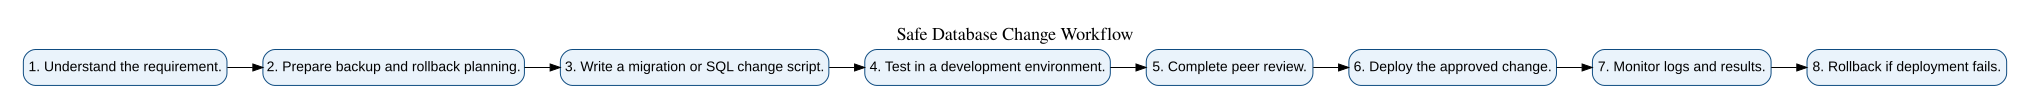

In [ ]:
database_change_steps = [
    "Understand the requirement.",
    "Prepare backup and rollback planning.",
    "Write a migration or SQL change script.",
    "Test in a development environment.",
    "Complete peer review.",
    "Deploy the approved change.",
    "Monitor logs and results.",
    "Rollback if deployment fails.",
]

database_change_diagram = validate_sequence(
    "ENG-CHANGE",
    database_change_steps,
    expected_keyword_groups=[
        ["requirement", "ticket"],
        ["backup", "rollback plan"],
        ["migration", "sql", "script"],
        ["test", "development", "dev"],
        ["review"],
        ["deploy", "release"],
        ["monitor", "log"],
        ["rollback"],
    ],
    title="Safe Database Change Workflow",
)

### Expected Output — ENG-CHANGE

- `✅ Overall status: Passed`
- An eight-step safety workflow
- Testing and review happen before deployment
- Monitoring happens after deployment
- Rollback is the final failure-response step

# 8. Progress Check

Run the next cell at any time. It shows which questions are complete and which still need work.

In [ ]:
completion_dashboard_df = completion_dashboard()

,section,task,status
0,ER Design,ER-1,Passed
1,API,API-Q1,Pending
2,API,API-Q2,Passed
3,API,API-Q3,Passed
4,API,API-Q4,Passed
5,API,API-Q5,Passed
6,SQL,Q1,Passed
7,SQL,Q2,Passed
8,SQL,Q3,Passed
9,SQL,Q4,Passed


status
Passed          20
Needs Review     5
Pending          1
Name: count, dtype: int64
